# Predict likelihood of loan default using customer financial data.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
sb.set()

In [4]:
#import loan data
loanData = pd.read_csv('Loan_Default.csv')
loanData.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [5]:
# Check structure
loanData.shape

(148670, 34)

In [6]:
loanData.dtypes

ID                             int64
year                           int64
loan_limit                    object
Gender                        object
approv_in_adv                 object
loan_type                     object
loan_purpose                  object
Credit_Worthiness             object
open_credit                   object
business_or_commercial        object
loan_amount                    int64
rate_of_interest             float64
Interest_rate_spread         float64
Upfront_charges              float64
term                         float64
Neg_ammortization             object
interest_only                 object
lump_sum_payment              object
property_value               float64
construction_type             object
occupancy_type                object
Secured_by                    object
total_units                   object
income                       float64
credit_type                   object
Credit_Score                   int64
co-applicant_credit_type      object
a

In [6]:
loanData.dtypes

ID                             int64
year                           int64
loan_limit                    object
Gender                        object
approv_in_adv                 object
loan_type                     object
loan_purpose                  object
Credit_Worthiness             object
open_credit                   object
business_or_commercial        object
loan_amount                    int64
rate_of_interest             float64
Interest_rate_spread         float64
Upfront_charges              float64
term                         float64
Neg_ammortization             object
interest_only                 object
lump_sum_payment              object
property_value               float64
construction_type             object
occupancy_type                object
Secured_by                    object
total_units                   object
income                       float64
credit_type                   object
Credit_Score                   int64
co-applicant_credit_type      object
a

## Data Cleaning

In [7]:
loanData = pd.read_csv("Loan_Default.csv")

loanData_clean = loanData.copy()

loanData_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [8]:
#check for missing values
loanData_clean.isnull().sum()

ID                               0
year                             0
loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
Secured_by                       0
total_units                      0
income                        9150
credit_type                      0
Credit_Score                     0
co-applicant_credit_type         0
age                            200
submission_of_applic

In [11]:
#find percentage of data missing in each coloumn
loanData_clean.isnull().mean() * 100

ID                            0.000000
year                          0.000000
loan_limit                    2.249277
Gender                        0.000000
approv_in_adv                 0.610749
loan_type                     0.000000
loan_purpose                  0.090133
Credit_Worthiness             0.000000
open_credit                   0.000000
business_or_commercial        0.000000
loan_amount                   0.000000
rate_of_interest             24.509989
Interest_rate_spread         24.644515
Upfront_charges              26.664425
term                          0.027578
Neg_ammortization             0.081388
interest_only                 0.000000
lump_sum_payment              0.000000
property_value               10.155378
construction_type             0.000000
occupancy_type                0.000000
Secured_by                    0.000000
total_units                   0.000000
income                        6.154571
credit_type                   0.000000
Credit_Score             

In [13]:
# Separate columns
num_cols = loanData_clean.select_dtypes(include=['int64', 'float64']).columns
cat_cols = loanData_clean.select_dtypes(include=['object']).columns

# Numerical columns
loanData_clean[num_cols] = loanData_clean[num_cols].fillna(
    loanData_clean[num_cols].median()
)

# Categorical columns
for col in cat_cols:
    loanData_clean[col] = loanData_clean[col].fillna(
        loanData_clean[col].mode()[0]
    )

# Check missing values
loanData_clean.isnull().sum()

ID                           0
year                         0
loan_limit                   0
Gender                       0
approv_in_adv                0
loan_type                    0
loan_purpose                 0
Credit_Worthiness            0
open_credit                  0
business_or_commercial       0
loan_amount                  0
rate_of_interest             0
Interest_rate_spread         0
Upfront_charges              0
term                         0
Neg_ammortization            0
interest_only                0
lump_sum_payment             0
property_value               0
construction_type            0
occupancy_type               0
Secured_by                   0
total_units                  0
income                       0
credit_type                  0
Credit_Score                 0
co-applicant_credit_type     0
age                          0
submission_of_application    0
LTV                          0
Region                       0
Security_Type                0
Status  

In [14]:
#Remove Useless Identifier Columns
loanData_clean.drop(columns=['ID'], inplace=True)


#Check and Remove Duplicate Rows
loanData_clean.duplicated().sum()
loanData_clean.drop_duplicates(inplace=True)


#Check Data Types
loanData_clean.dtypes


#Check for Impossible / Unrealistic Values
loanData_clean[loanData_clean['income'] < 0]
loanData_clean[loanData_clean['loan_amount'] < 0]
loanData_clean[loanData_clean['rate_of_interest'] > 100]


#Explore Outliers
loanData_clean.describe()


#Check Target Variable Balance
loanData_clean['Status'].value_counts()

Status
0    112031
1     36639
Name: count, dtype: int64

## Exploratory Data Analysis

In [17]:
# STEP 14 — Create Final Dataset for EDA

loanData_final = loanData_clean.copy()


# STEP 15 — Define Variables for EDA

categorical_vars = [
    'Gender',
    'loan_type',
    'loan_purpose',
    'occupancy_type',
    'approv_in_adv',
    'business_or_commercial',
    'interest_only',
    'Neg_ammortization',
    'Region'
]

numerical_vars = [
    'income',
    'loan_amount',
    'Credit_Score',
    'rate_of_interest',
    'LTV',
    'dtir1',
    'property_value',
    'term'
]


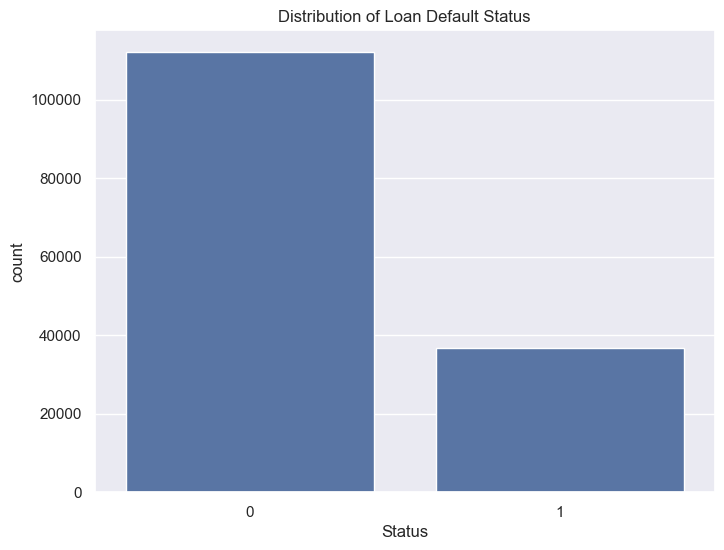

In [25]:
#Target Variable Distribution
#Compare number of defaulted vs non-defaulted loans to check dataset balance.

plt.figure(figsize=(8,6))

sb.countplot(
    x='Status',
    data=loanData_final
)

plt.title('Distribution of Loan Default Status')

plt.show()

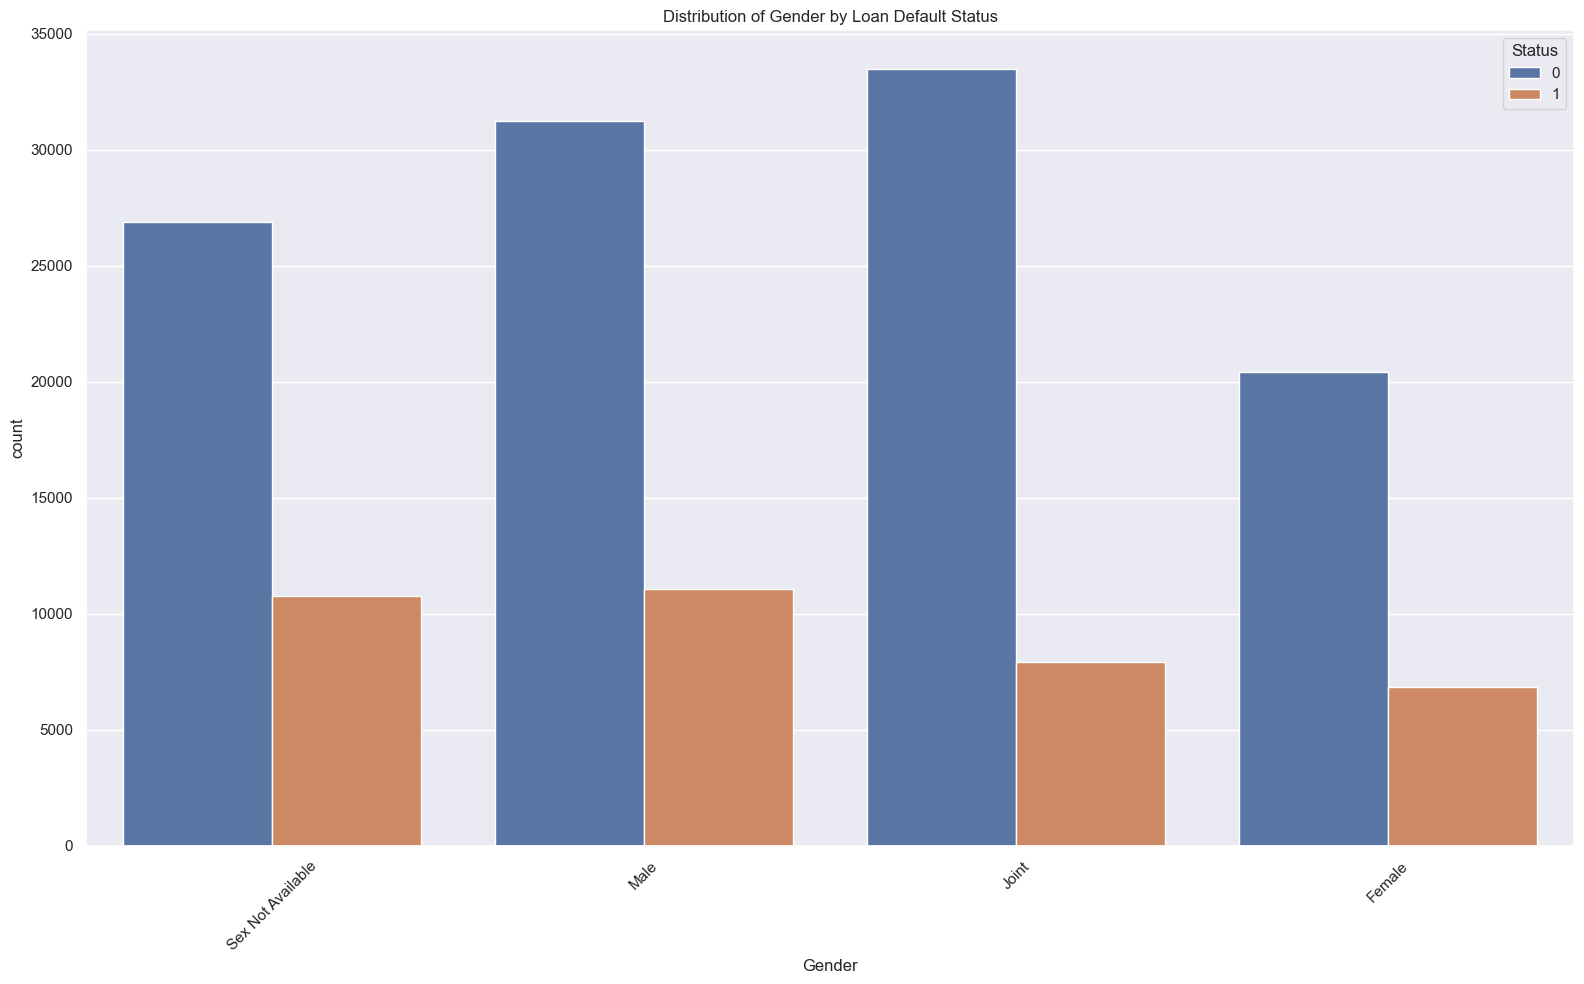

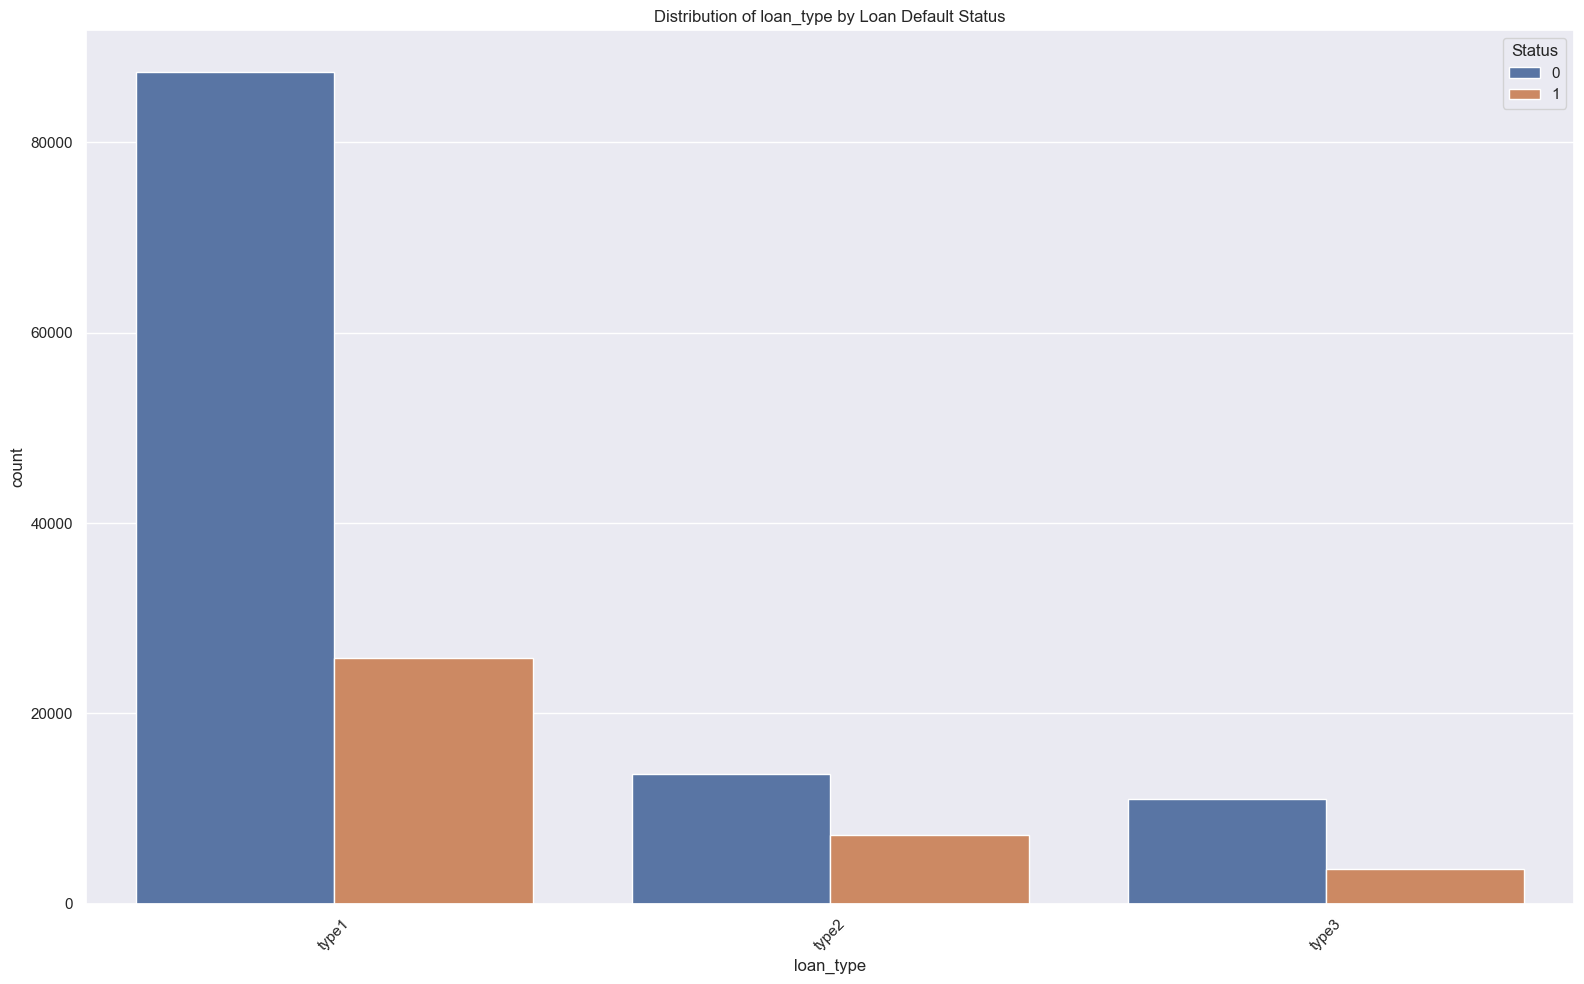

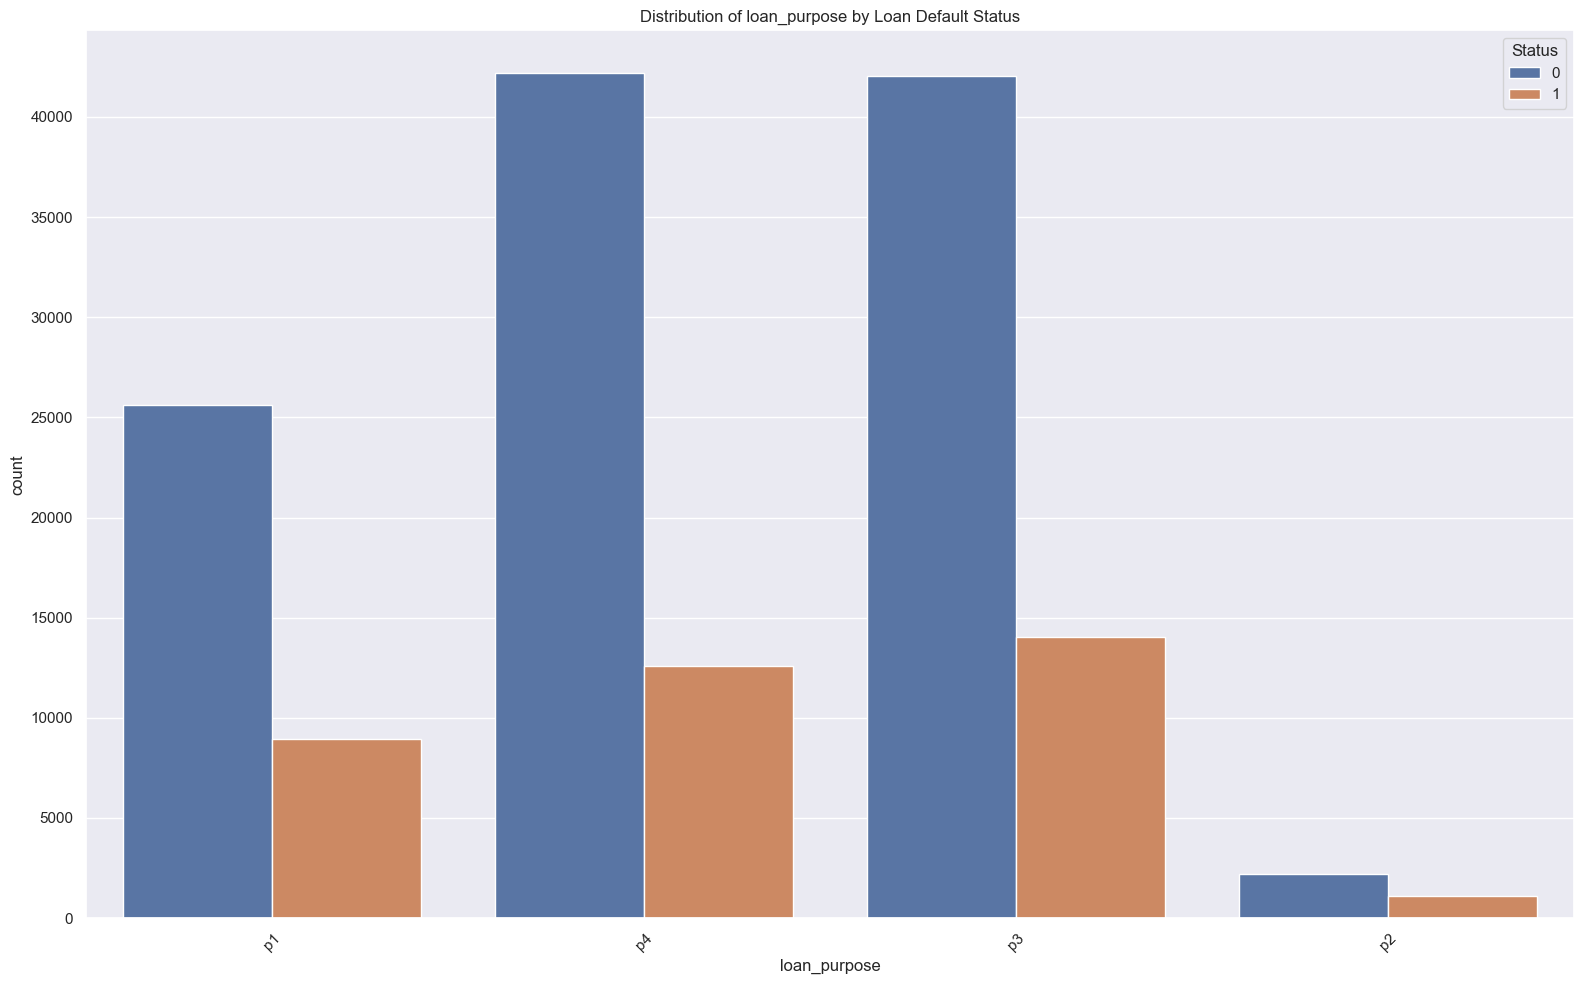

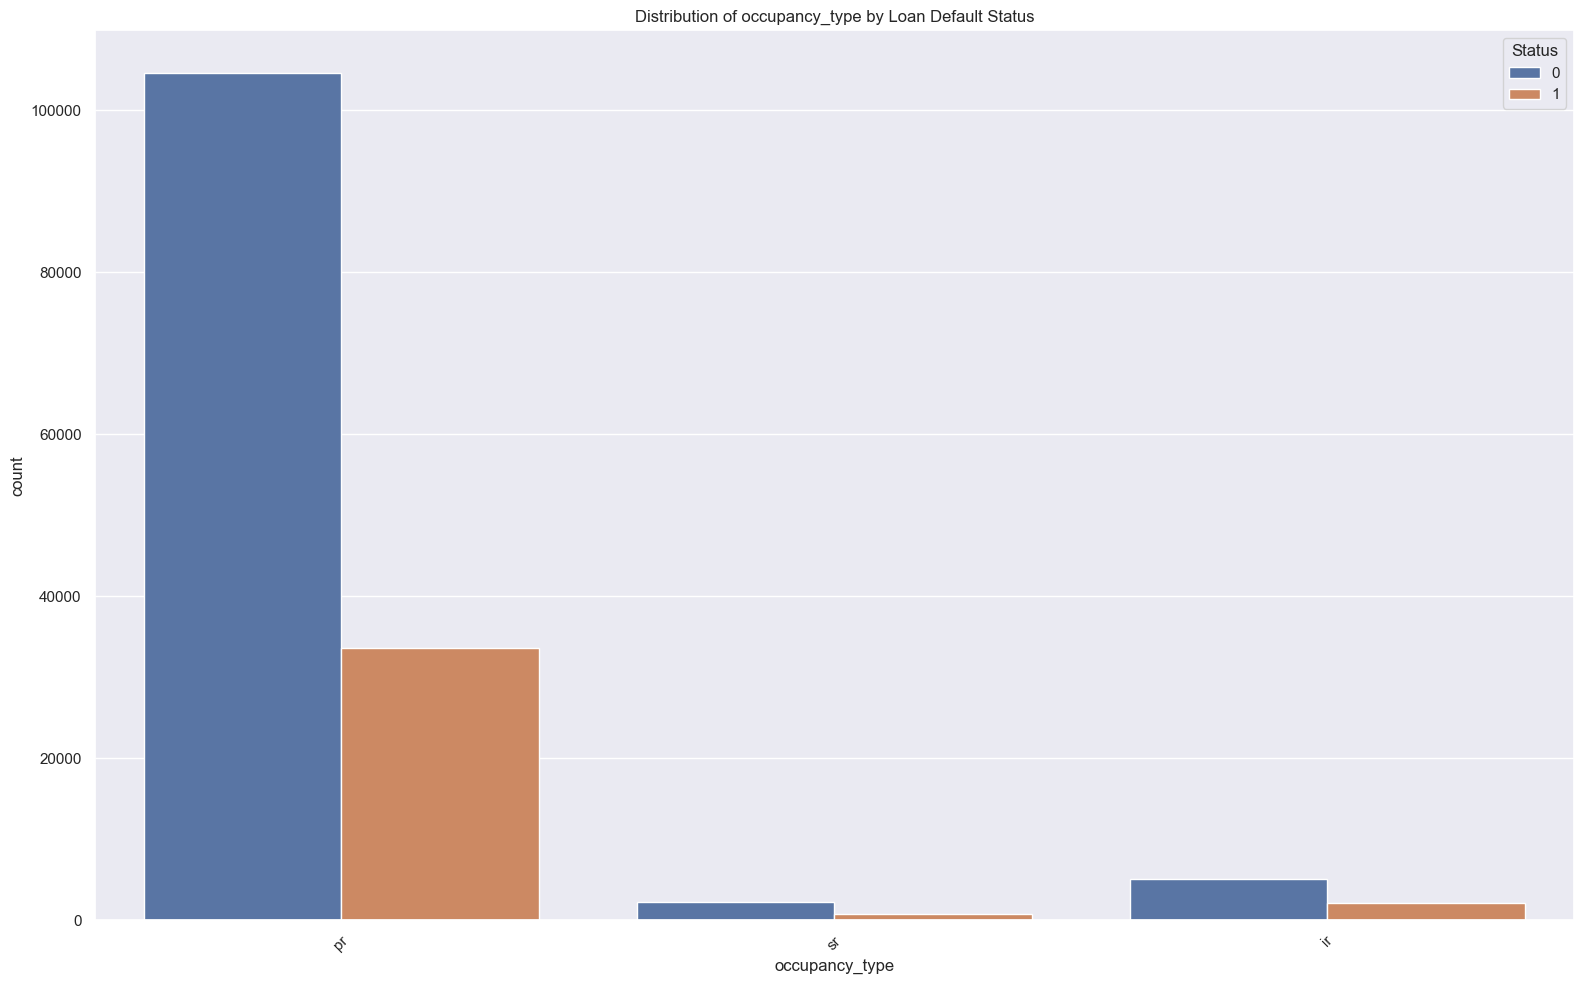

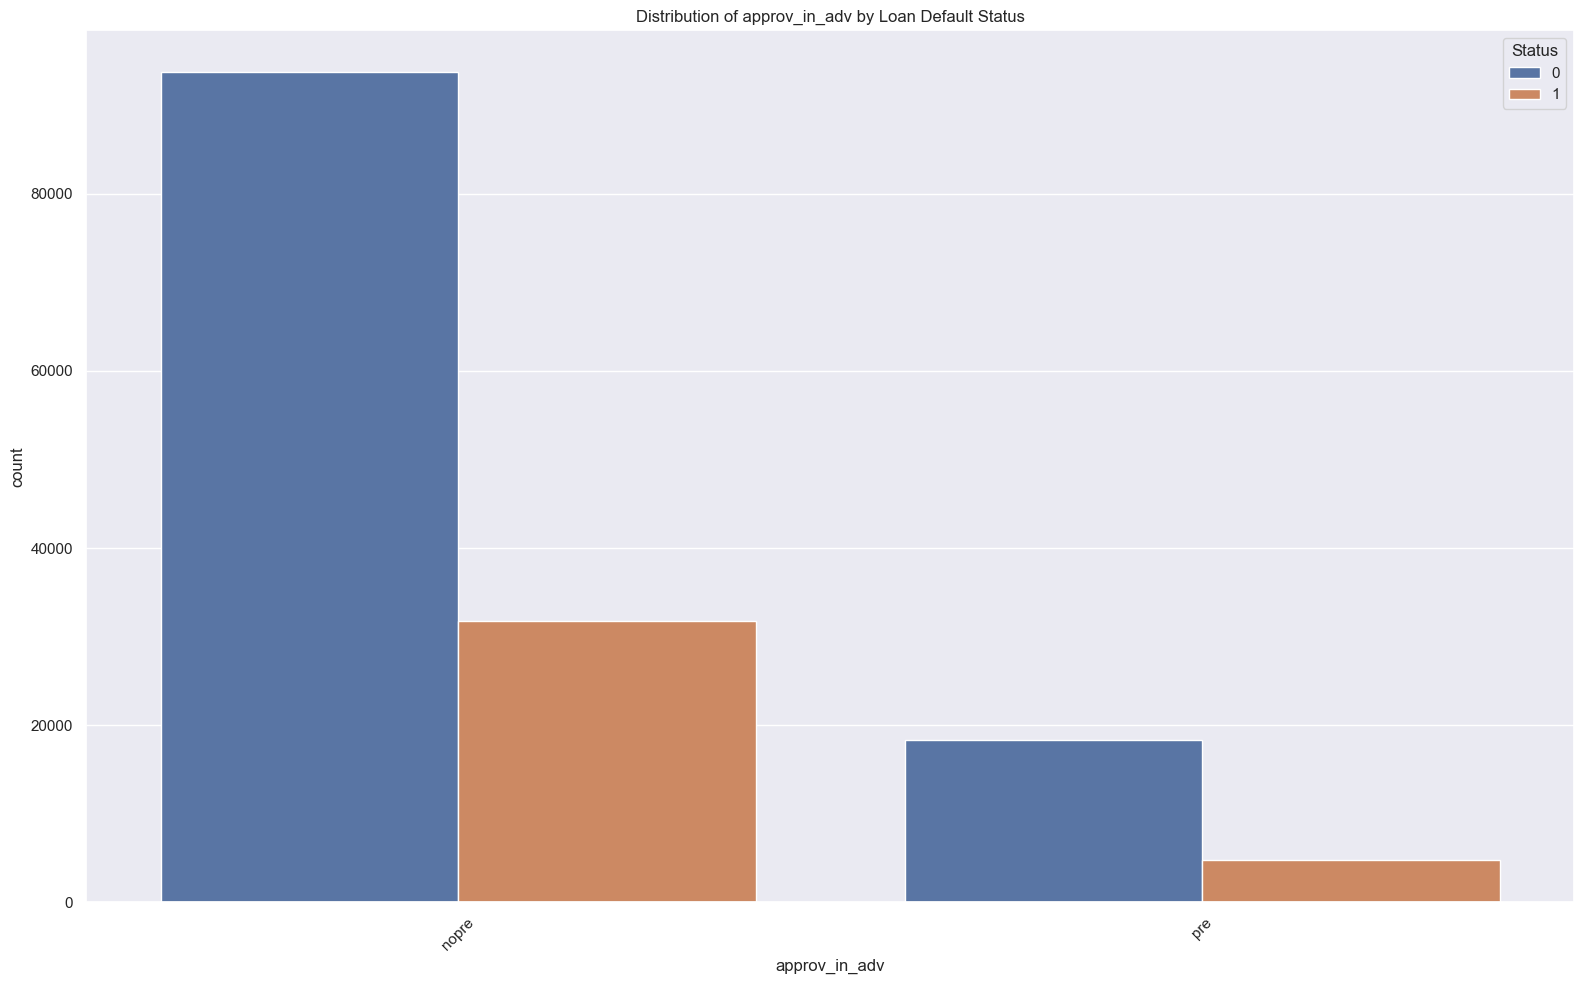

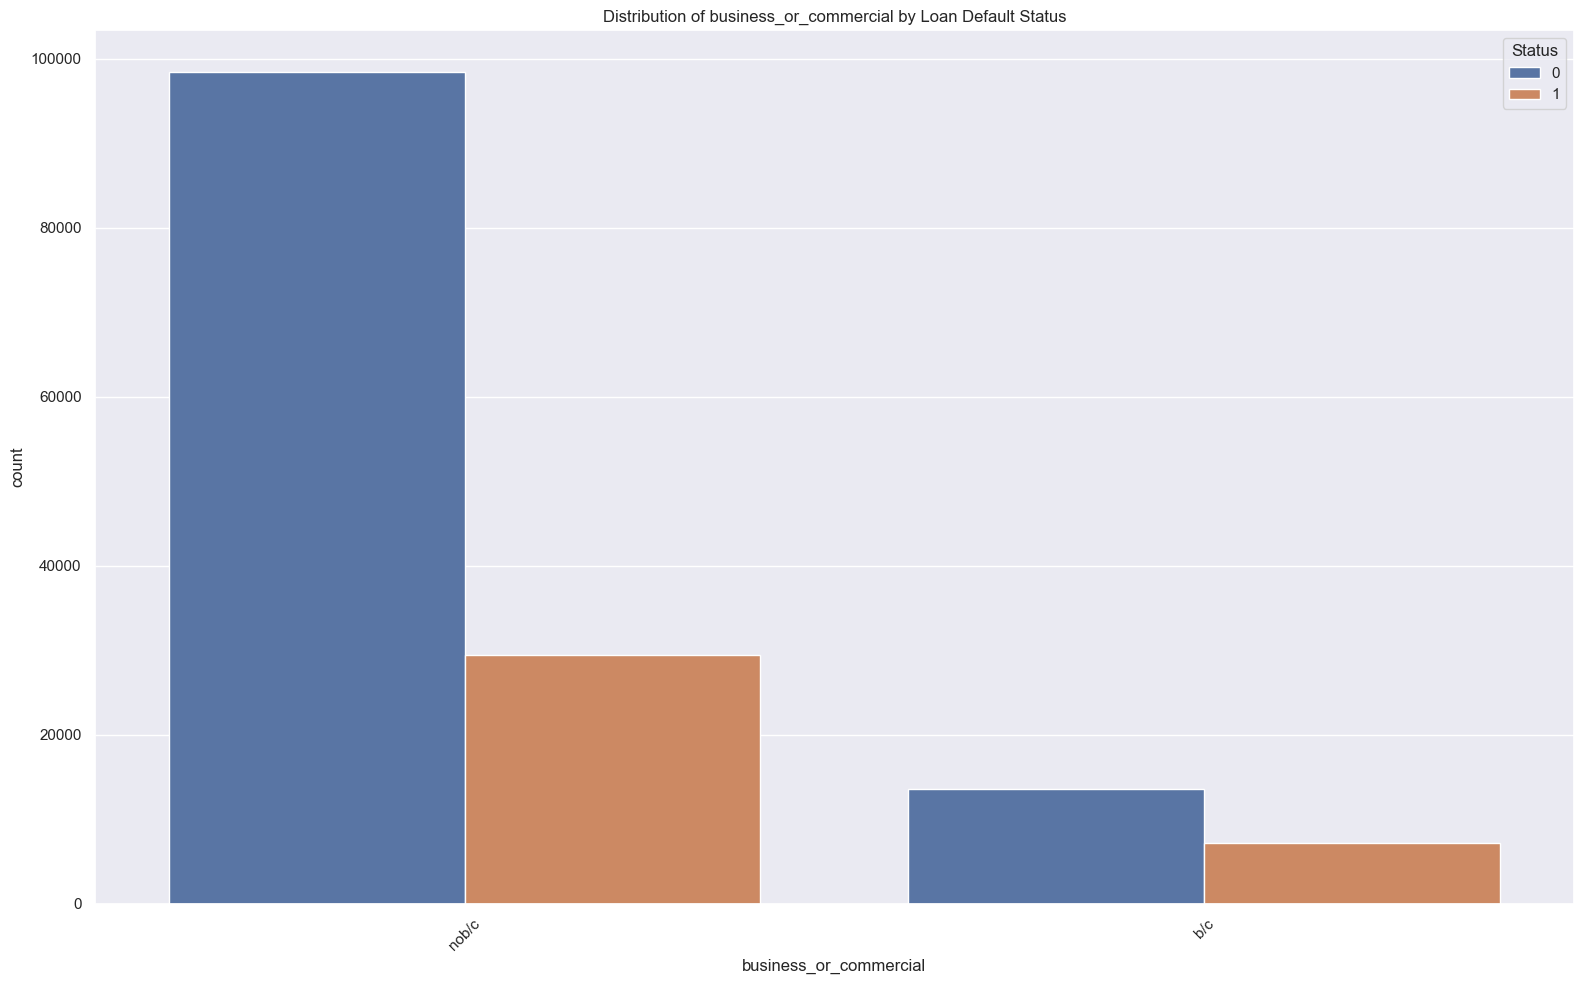

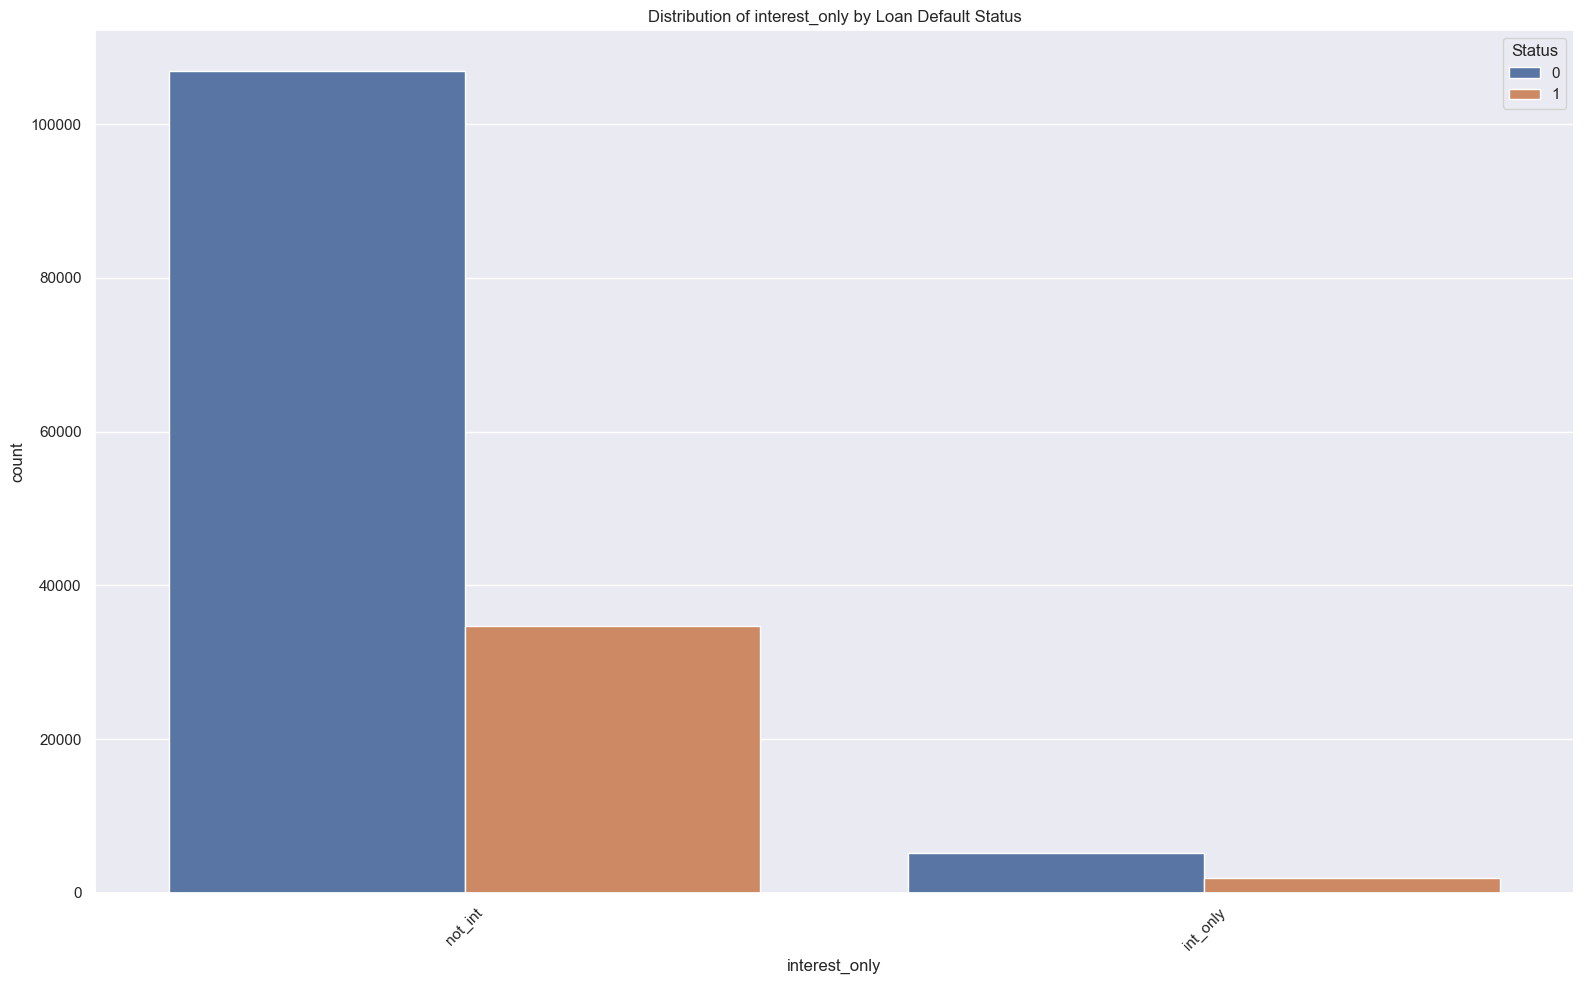

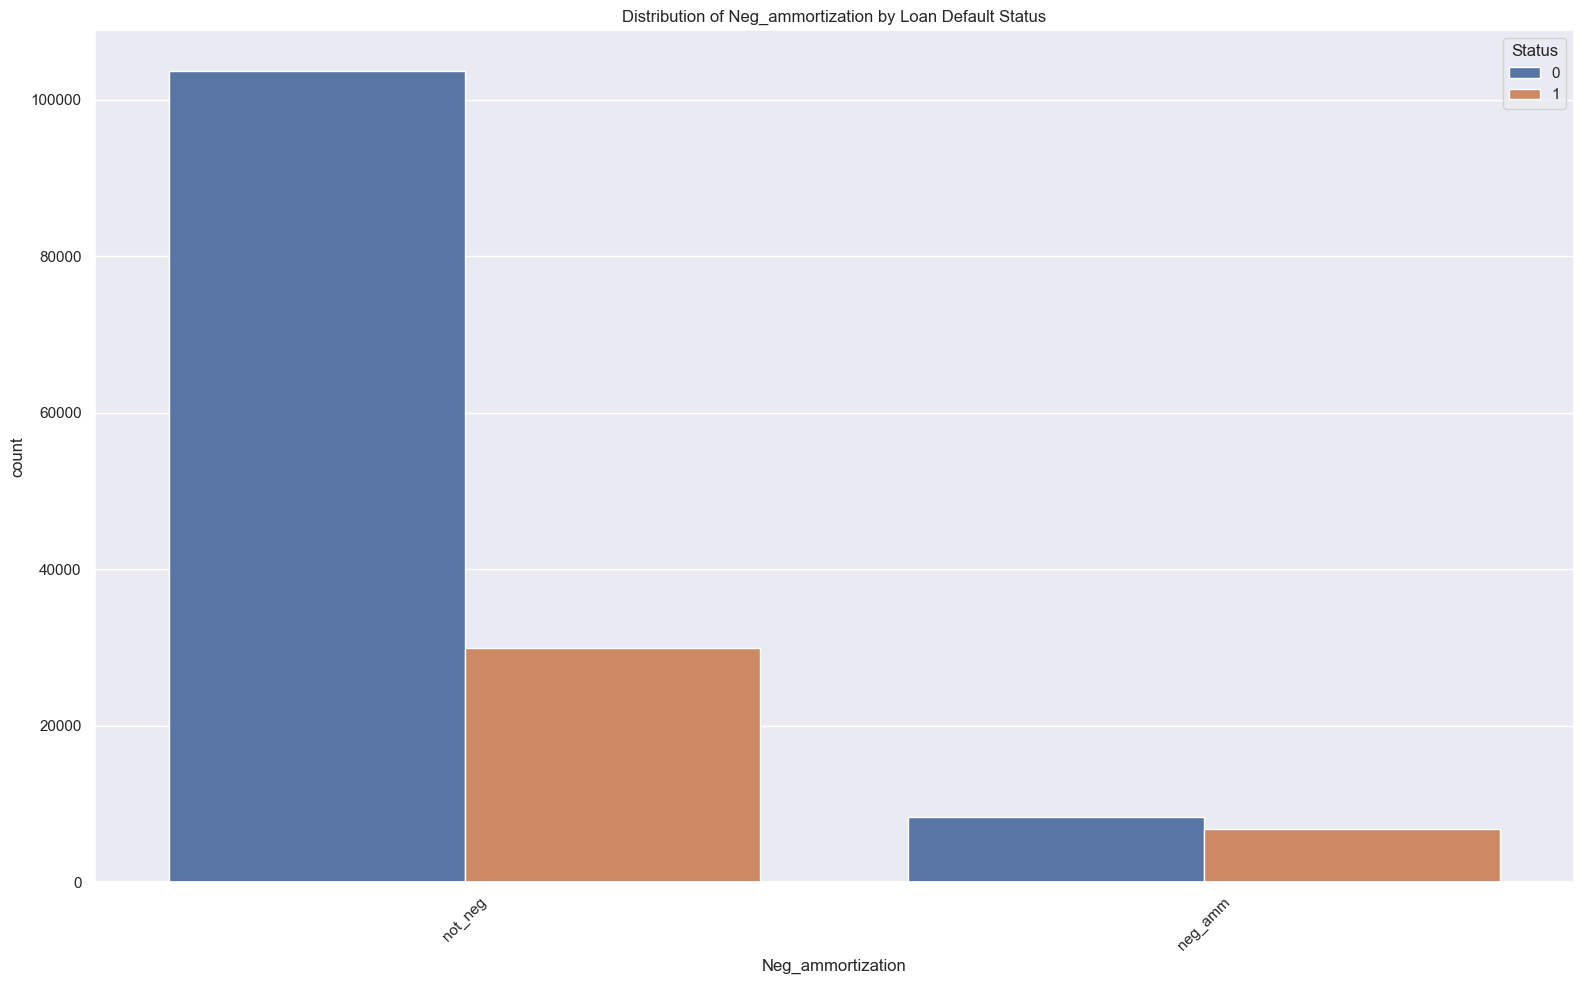

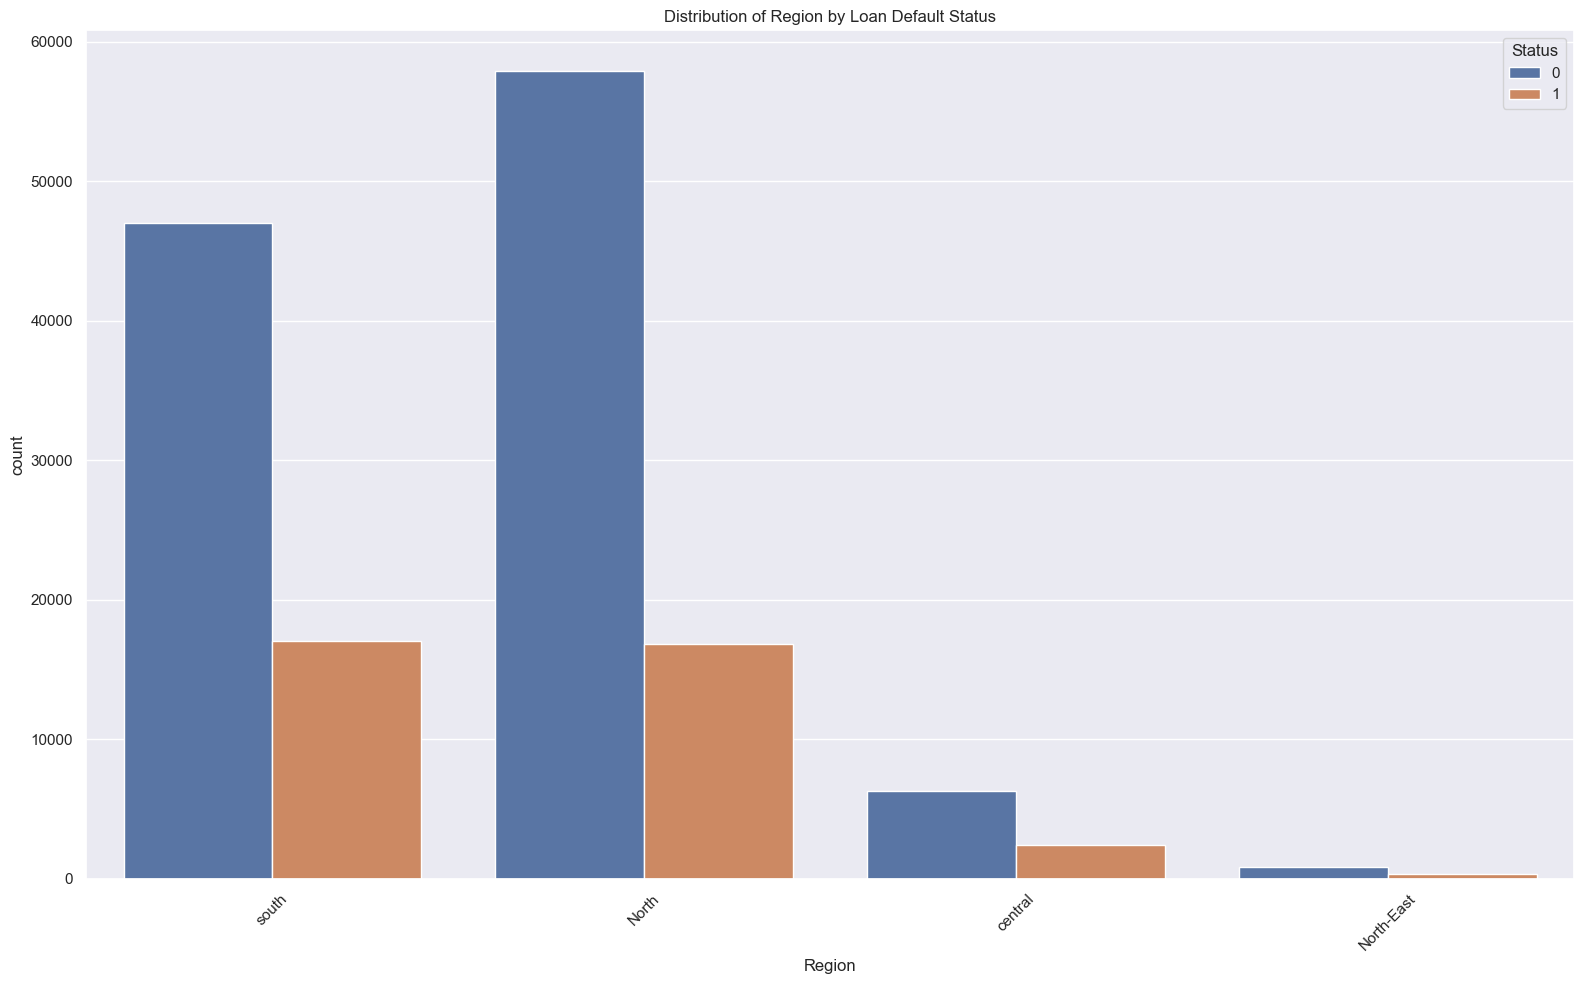

In [27]:
#Categorical Variable Analysis
#Compare categorical variables against loan default status to identify risk patterns between categories.

for var in categorical_vars:

    plt.figure(figsize=(16,10))

    sb.countplot(
        x=var,
        hue='Status',
        data=loanData_final
    )

    plt.title(f'Distribution of {var} by Loan Default Status')

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()


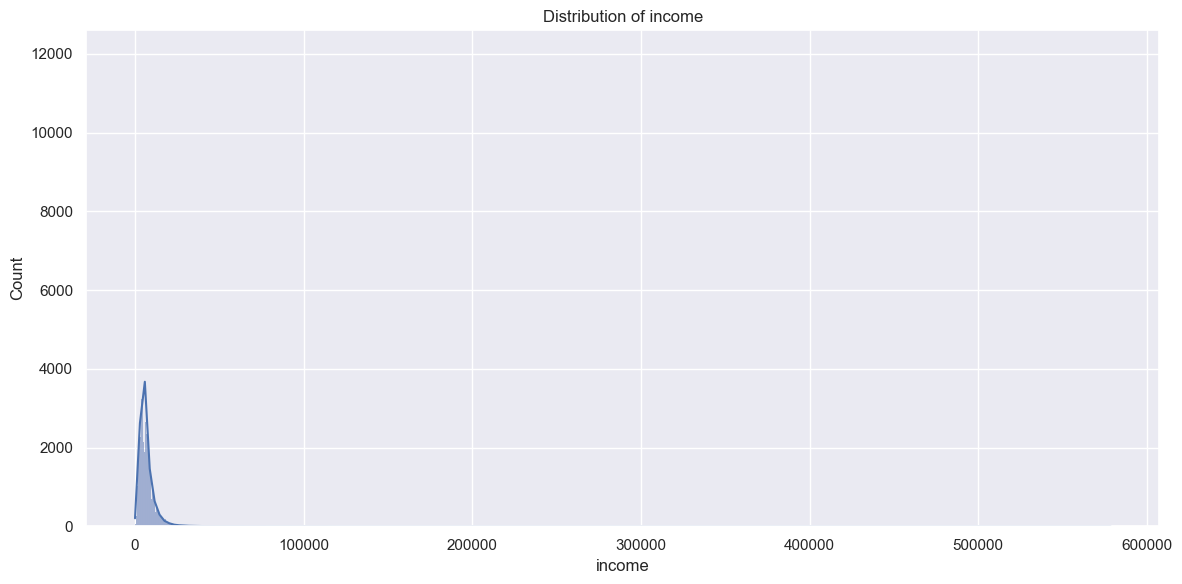

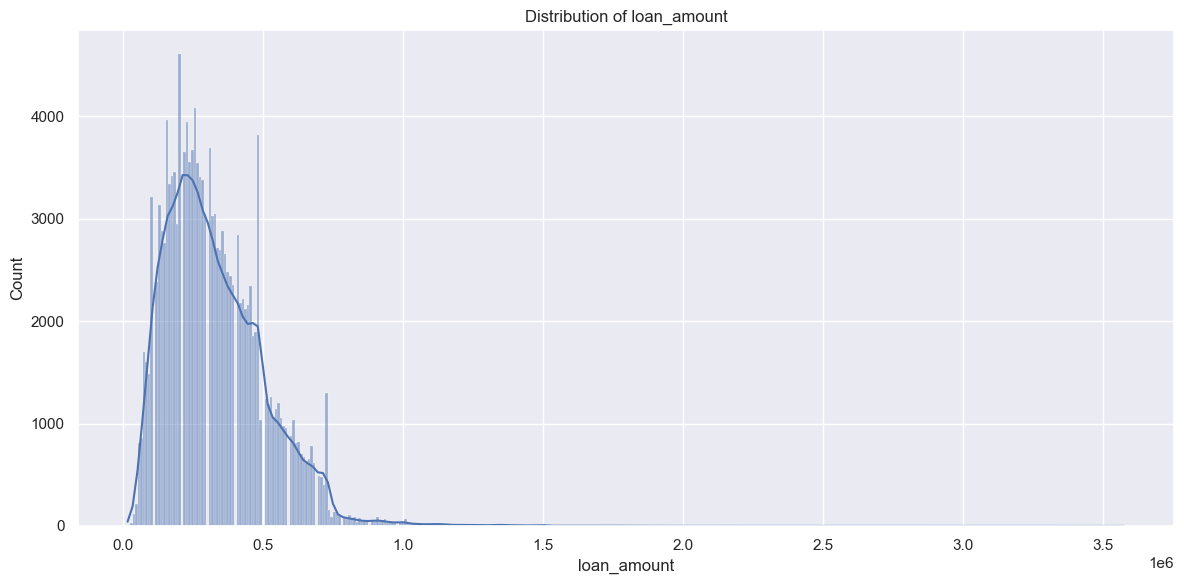

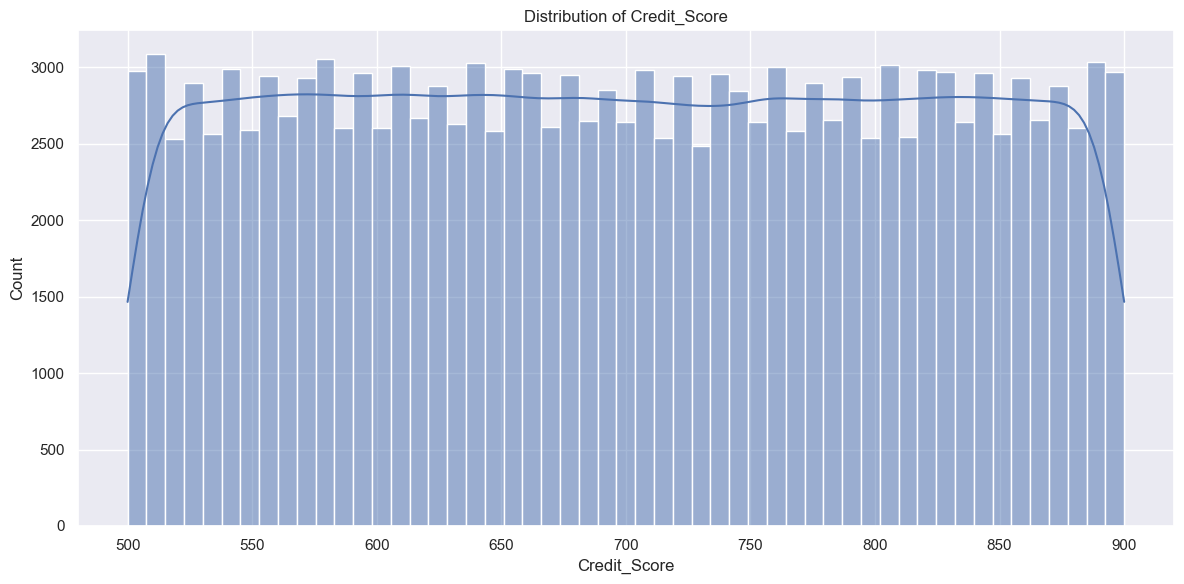

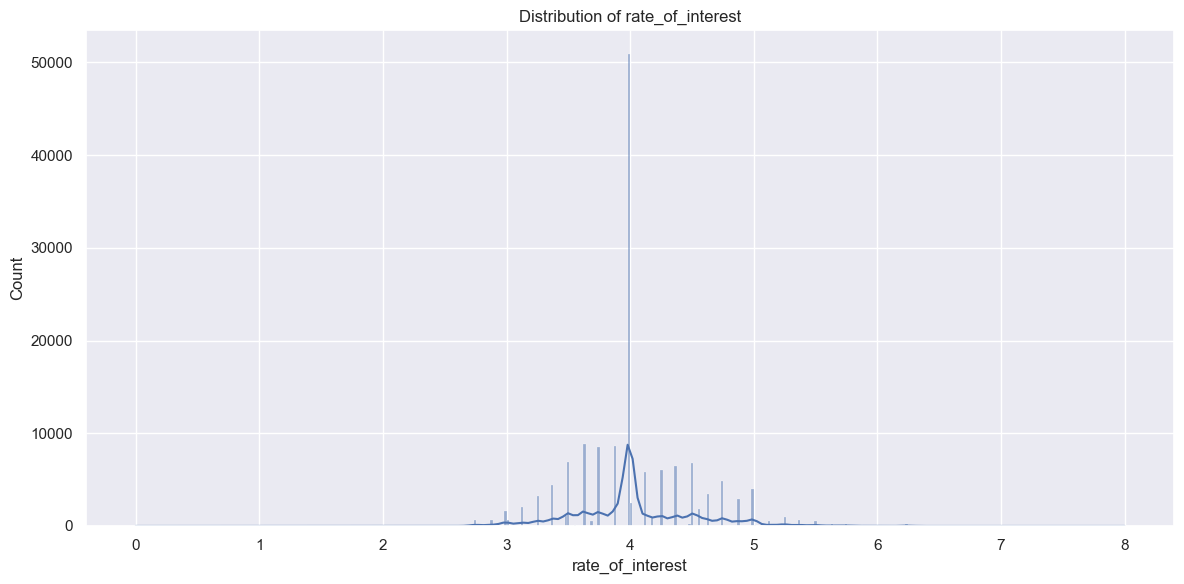

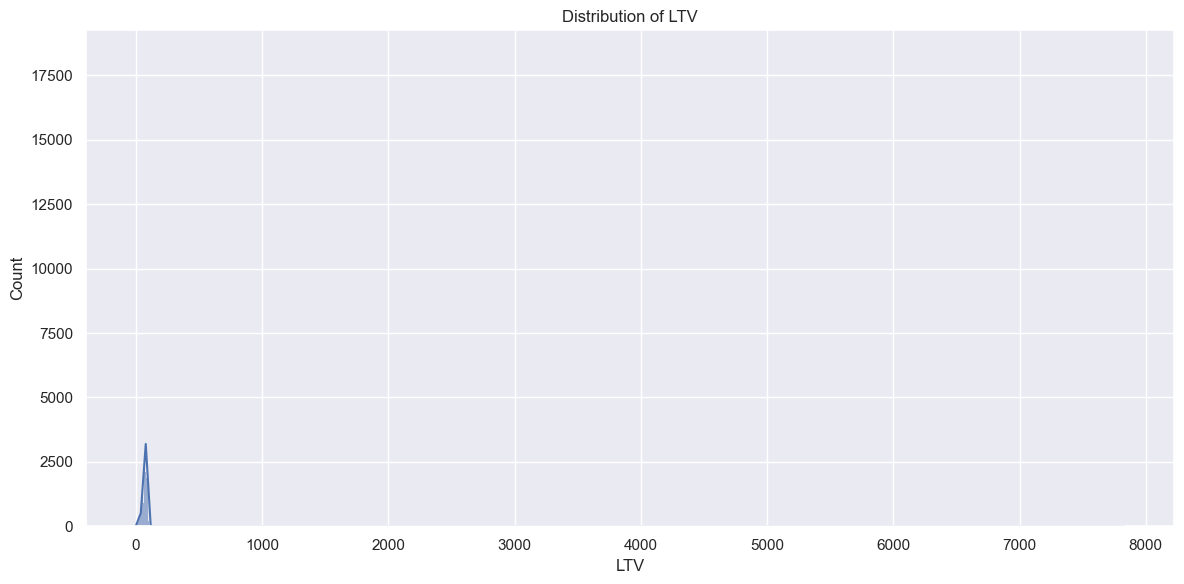

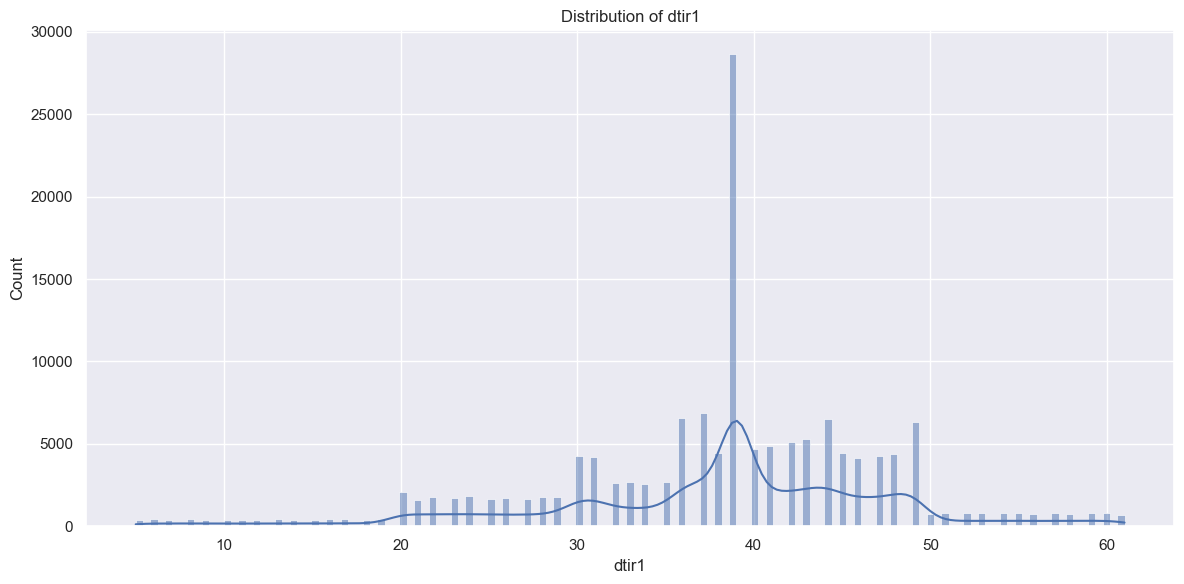

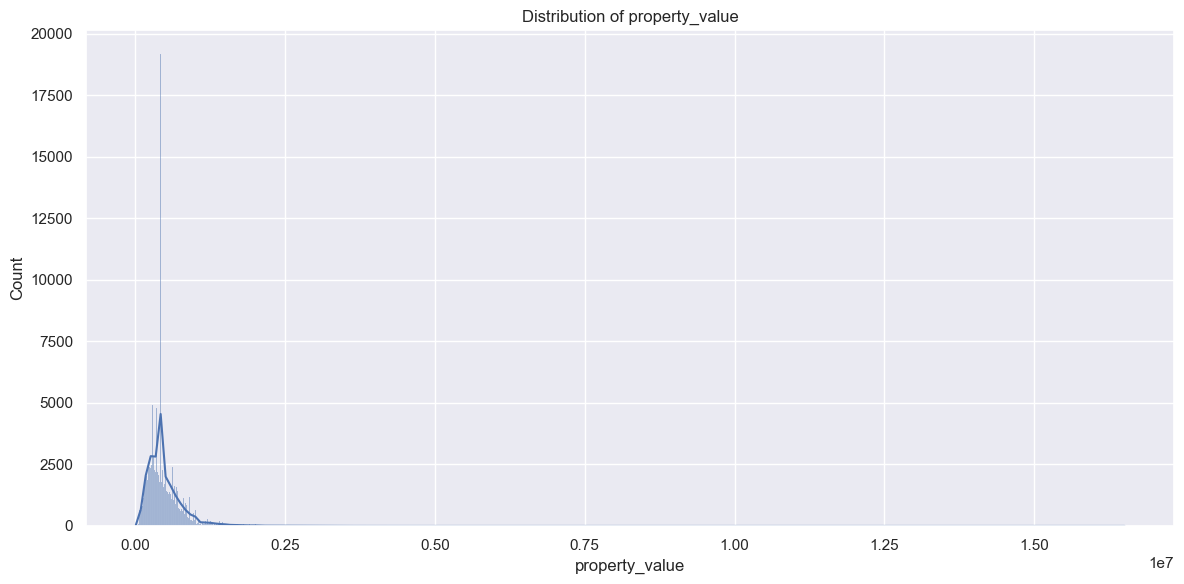

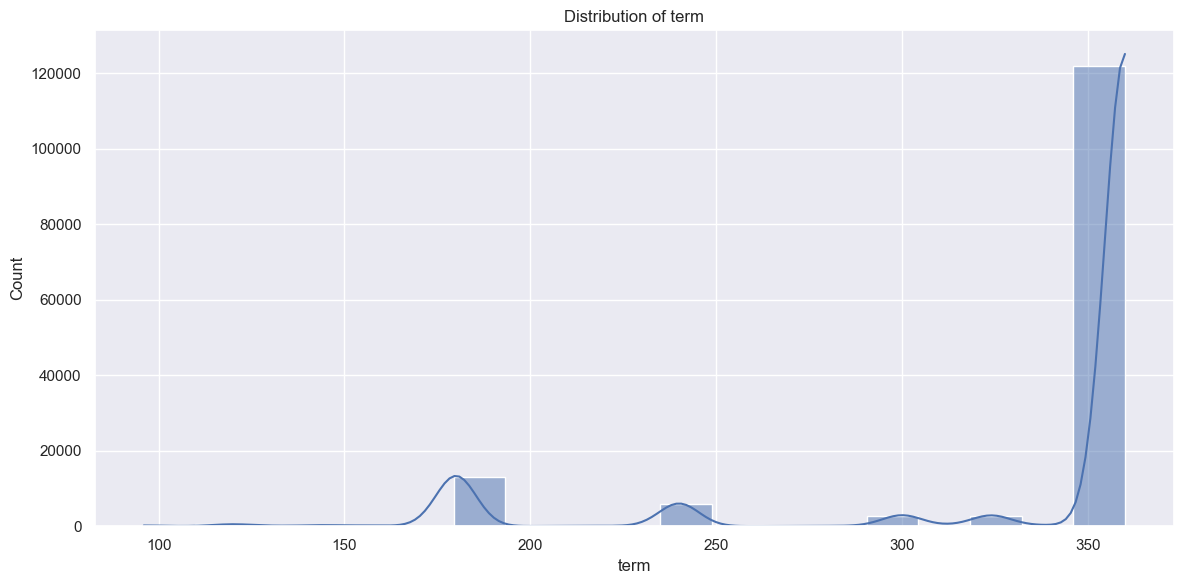

In [29]:
#Numerical Variable Distribution
#Visualize numerical variable distributions to identify spread, skewness, and outliers.

for var in numerical_vars:

    plt.figure(figsize=(12,6))

    sb.histplot(
        loanData_final[var],
        kde=True
    )

    plt.title(f'Distribution of {var}')

    plt.tight_layout()

    plt.show()


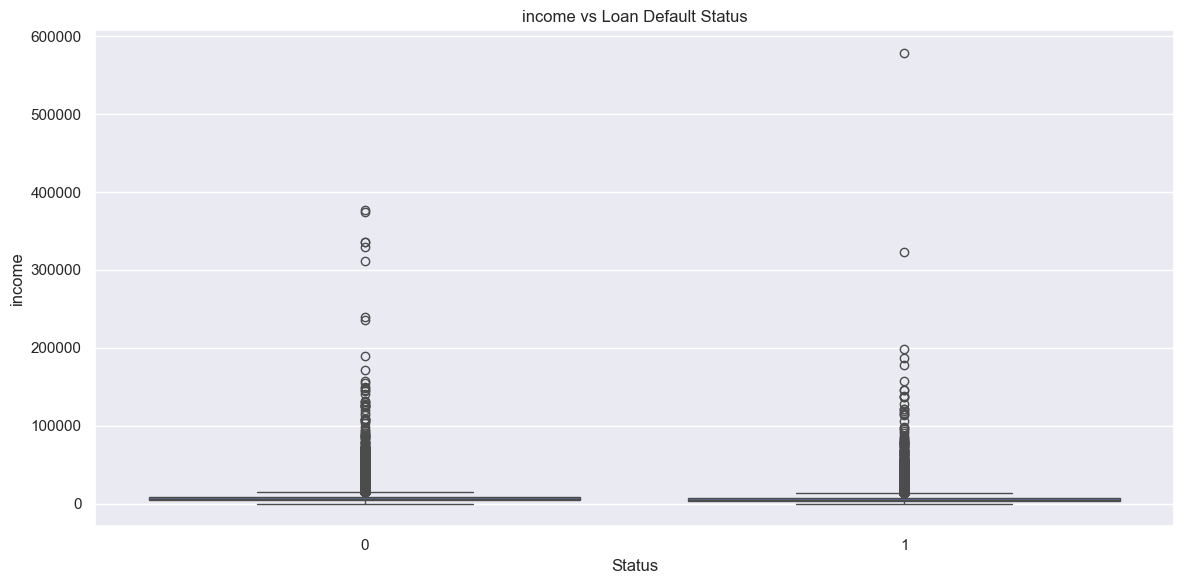

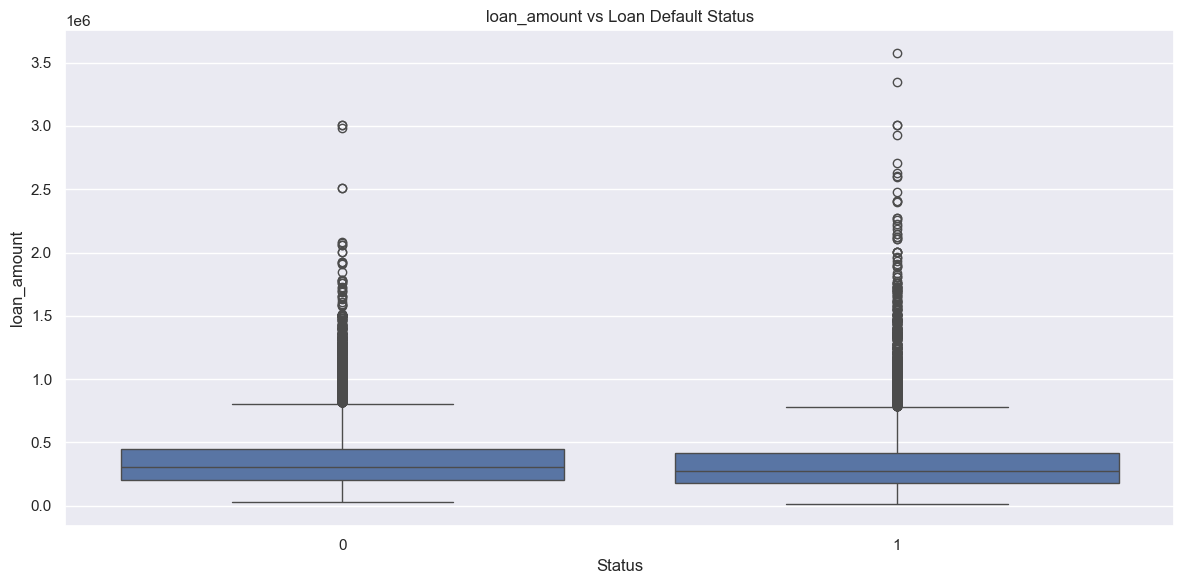

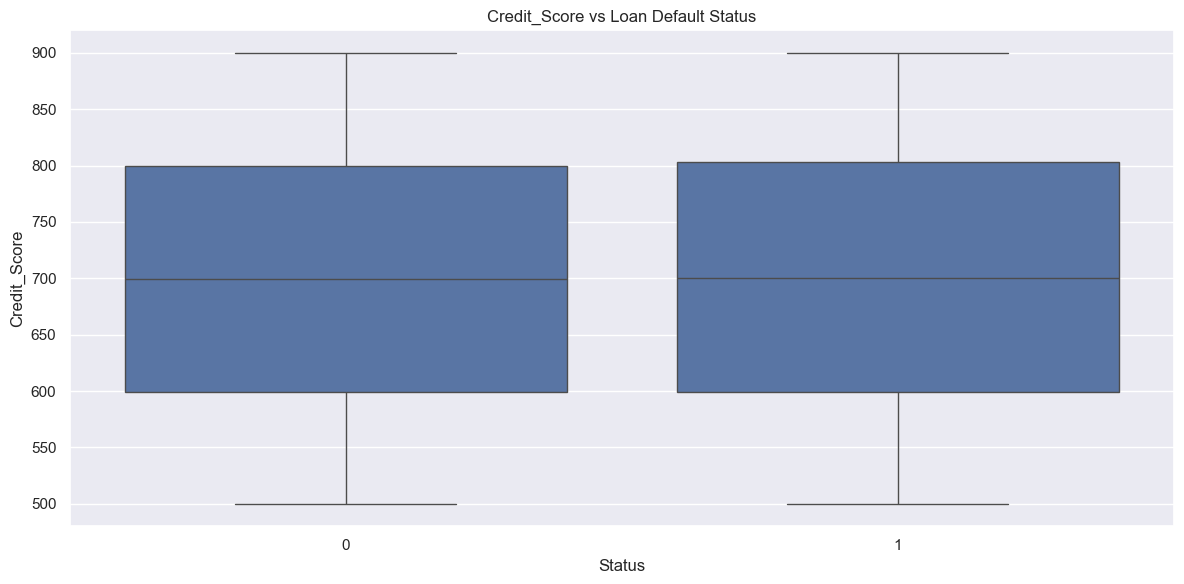

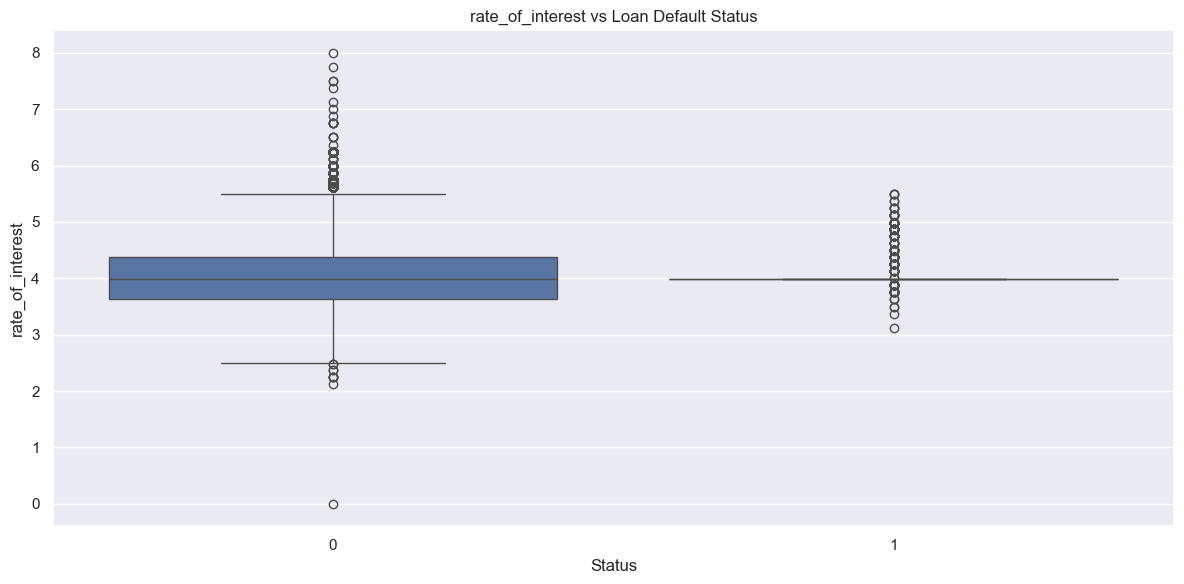

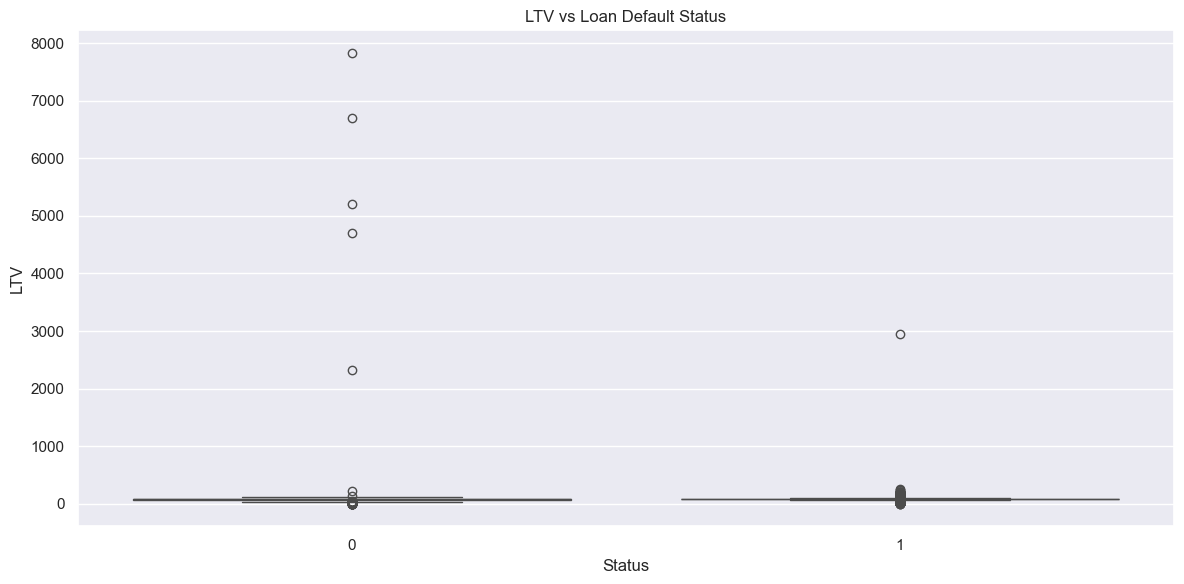

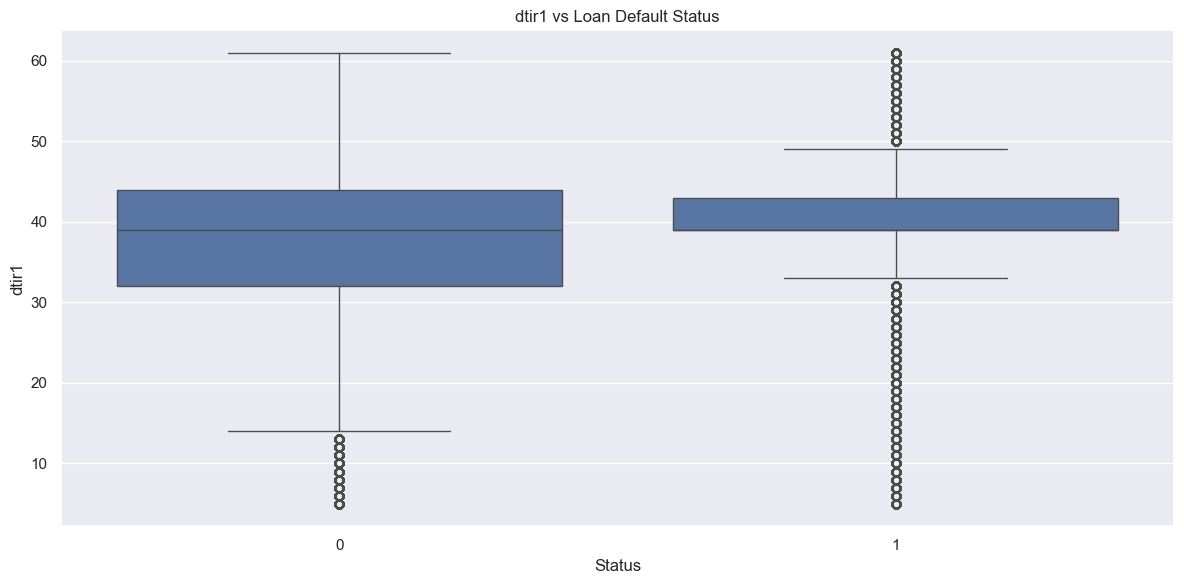

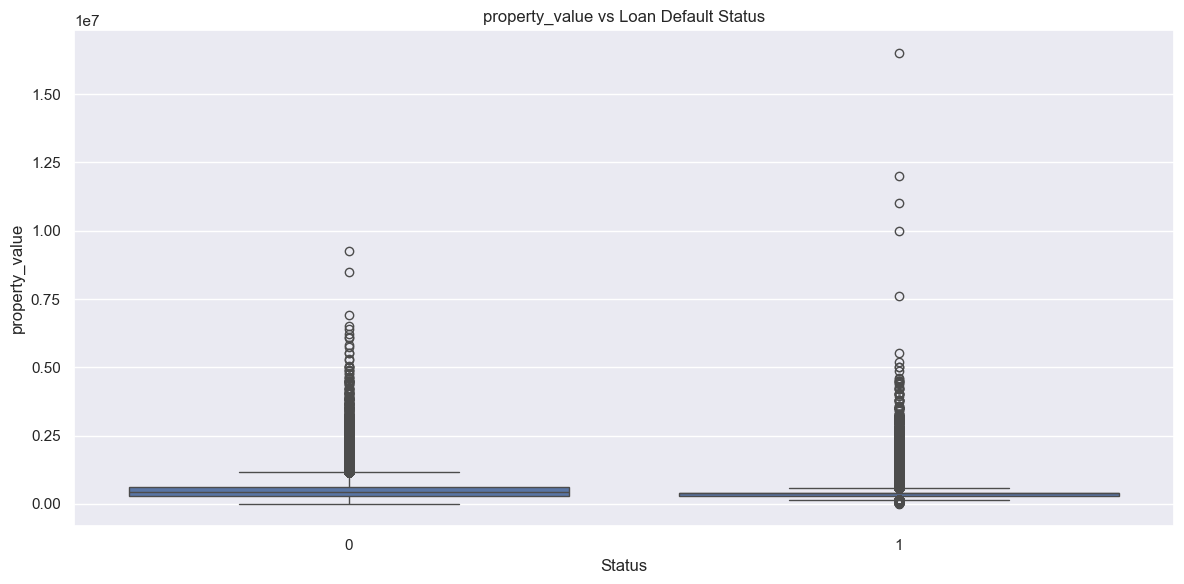

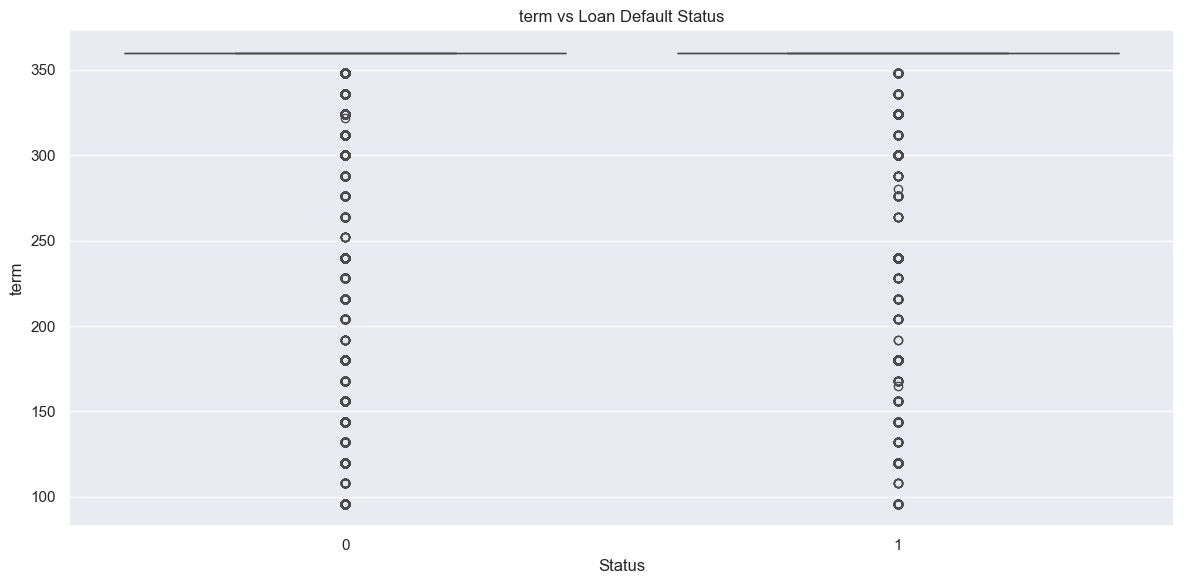

In [30]:
#Numerical Variables vs Loan Default
#Compare numerical variables between defaulted and non-defaulted loans to identify trends.

for var in numerical_vars:

    plt.figure(figsize=(12,6))

    sb.boxplot(
        x='Status',
        y=var,
        data=loanData_final
    )

    plt.title(f'{var} vs Loan Default Status')

    plt.tight_layout()

    plt.show()


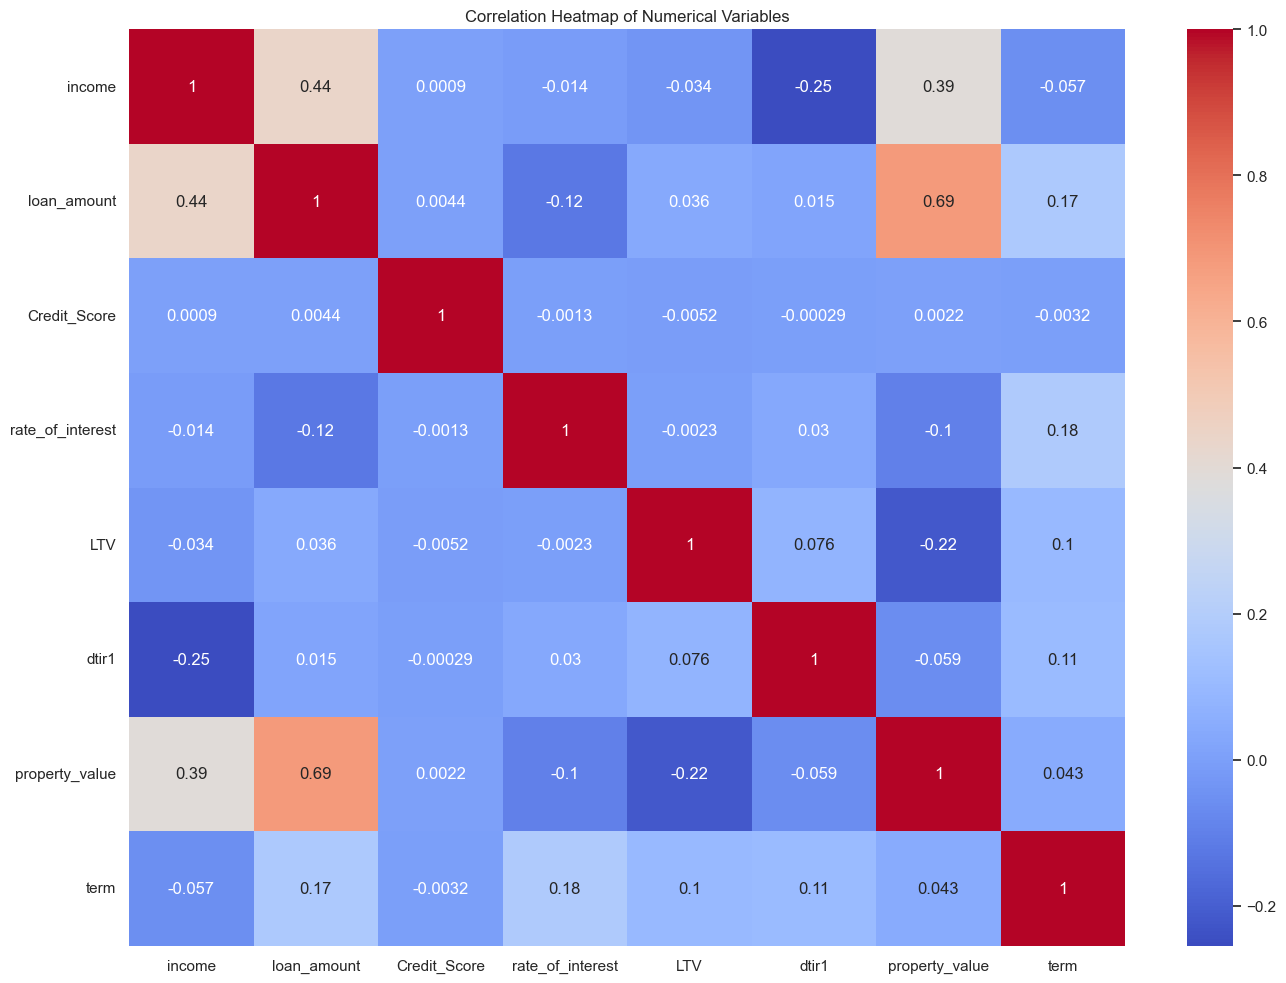

In [31]:
#Correlation Heatmap
#Measure relationships between numerical variables to identify strong correlations and patterns.

plt.figure(figsize=(14,10))

sb.heatmap(
    loanData_final[numerical_vars].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap of Numerical Variables')

plt.tight_layout()

plt.show()

## EDA Conclusion

### From the exploratory data analysis, several important patterns related to loan default risk were identified. The target variable (`Status`) showed a moderate class imbalance, with non-default cases forming the majority of observations. This suggests that evaluation metrics beyond simple accuracy may be important during model development.

### Categorical variable analysis indicated that certain loan characteristics, such as interest-only loans and business/commercial loans, appeared to have relatively higher default proportions compared to other categories.

### For numerical variables, borrowers with lower credit scores and higher debt-to-income ratios (`dtir1`) generally showed higher default tendencies. Variables such as loan amount, property value, and LTV ratio also displayed meaningful variation across default groups.

### The correlation heatmap showed that some financial variables were moderately related, although no extremely strong multicollinearity was observed. This suggests that most selected variables may still provide useful predictive information for machine learning models.

### Overall, the EDA suggests that borrower financial strength, loan structure, and repayment burden are likely important factors influencing loan default risk. These findings support proceeding to supervised machine learning models such as Logistic Regression, Random Forest, and XGBoost for predictive modelling.


## Supervised Learning

In [40]:
#Feature Encoding
#Find all object/text columns
object_cols = loanData_final.select_dtypes(include='object').columns
#Convert all categorical text variables into numerical format
loanData_encoded = pd.get_dummies(
    loanData_final,
    columns=object_cols,
    drop_first=True
)
loanData_encoded.head()

#Define Features and Target
#X = predictor variables, y = target variable to predict

X = loanData_encoded.drop('Status', axis=1)
y = loanData_encoded['Status']

#Train Test Split
#train model using training data

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#Feature Scaling
#standardize numerical values

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Logistic Regression Model

from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

#Predictions

y_pred = log_model.predict(X_test_scaled)

#Model Evaluation

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Accuracy Score:")
print(accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

#ROC AUC Score

from sklearn.metrics import roc_auc_score
y_prob = log_model.predict_proba(X_test_scaled)[:,1]
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

Accuracy Score:
0.8713593865608394

Confusion Matrix:
[[22197   297]
 [ 3528  3712]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.99      0.92     22494
           1       0.93      0.51      0.66      7240

    accuracy                           0.87     29734
   macro avg       0.89      0.75      0.79     29734
weighted avg       0.88      0.87      0.86     29734

ROC-AUC Score: 0.8602826929415678


***Accuracy Score***
Measures the overall correctness of the model. An accuracy score of 0.871 means that approximately 87.1% of all borrower outcomes were predicted correctly by the Logistic Regression model. However, accuracy alone may be misleading in imbalanced datasets where non-default borrowers form the majority class.

***Confusion Matrix***
The confusion matrix breaks predictions into correct and incorrect classifications.

* True Negatives (22197): Borrowers who were actually safe and correctly predicted as safe.
* False Positives (297): Borrowers who were actually safe but incorrectly predicted as defaulters.
* False Negatives (3528): Borrowers who actually defaulted but were incorrectly predicted as safe borrowers. This is particularly important in finance because it may lead to financial losses for lenders.
* True Positives (3712): Borrowers who actually defaulted and were correctly identified as risky borrowers.

***Precision***
Precision measures how reliable the model’s default predictions are. A precision score of 0.93 for the default class means that when the model predicts a borrower will default, it is correct 93% of the time. High precision indicates strong confidence in predicted risky borrowers.

***F1-Score***
The F1-score balances both precision and recall into a single metric. A higher F1-score indicates a better balance between identifying risky borrowers and avoiding incorrect predictions. The default class achieved an F1-score of 0.66, indicating moderate overall performance in detecting defaults.

***Support***
Support refers to the number of actual observations in each class. For example, the support value of 7240 for the default class indicates that there were 7240 actual default borrowers in the testing dataset.

***Macro Average***
Macro average calculates the average metric score across both classes equally, regardless of class size. This is useful in imbalanced datasets because it prevents the majority class from dominating the evaluation.

***Weighted Average***
Weighted average calculates the average metric score while taking class size into account. Since non-default borrowers form the majority class, weighted averages are more influenced by the model’s performance on safe borrowers.

***ROC-AUC Score***
The ROC-AUC score measures the model’s ability to distinguish between default and non-default borrowers across different classification thresholds. A ROC-AUC score of 0.86 indicates that the Logistic Regression model has strong discriminatory ability and performs significantly better than random guessing in identifying risky borrowers.
 

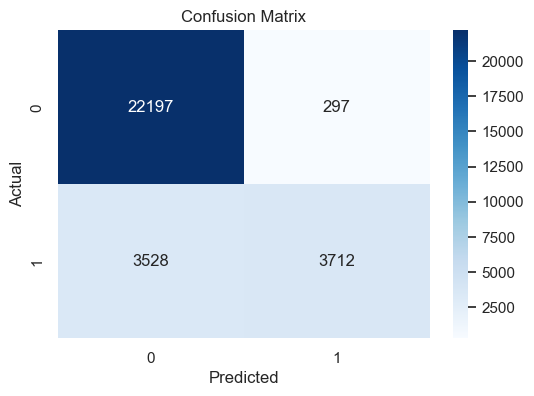

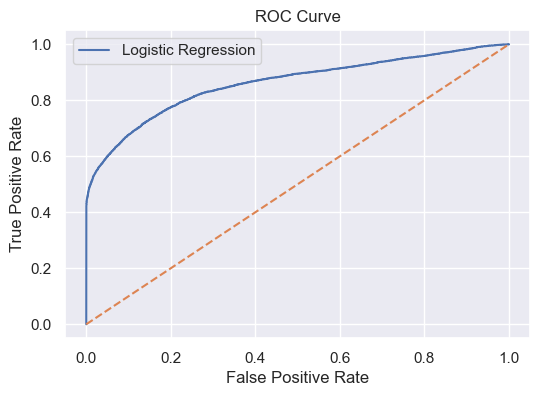

In [43]:
#Matrix Heatmap
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

#ROC Curve
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label='Logistic Regression')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")
plt.legend()

plt.show()



In [46]:
#Extract Logistic Regression Coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
})

coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

coefficients.head(20)

,Feature,Coefficient
35,credit_type_EQUI,3.309812
44,submission_of_application_to_inst,0.639542
9,LTV,0.604283
19,loan_purpose_p3,0.202189
11,loan_limit_ncf,0.192232
18,loan_purpose_p2,0.154400
1,loan_amount,0.125241
40,age_55-64,0.107380
10,dtir1,0.106851
21,Credit_Worthiness_l2,0.098772


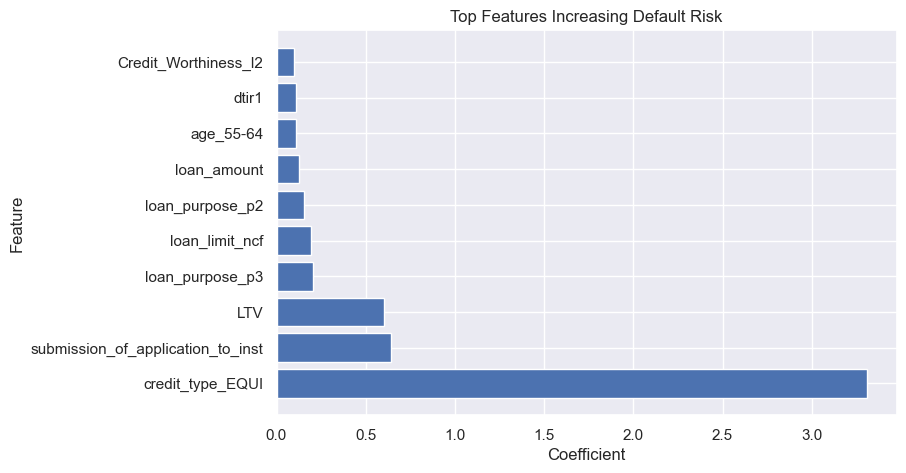

In [47]:
top_features = coefficients.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top_features['Feature'],
    top_features['Coefficient']
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.title("Top Features Increasing Default Risk")

plt.show()

## Logistic Regression Summary

### A Logistic Regression model was developed to predict loan default risk using borrower financial information and loan-related variables. The model was trained using historical borrower data, where the target variable (`Status`) represented whether a borrower defaulted or not.

### Before modelling, categorical variables were converted into numerical format using feature encoding, and numerical variables were standardized using feature scaling. The dataset was then split into training and testing sets to evaluate model performance on unseen data.

### The Logistic Regression model achieved an accuracy score of approximately 87%, indicating strong overall predictive performance. The model also achieved a ROC-AUC score of approximately 0.86, suggesting good ability to distinguish between default and non-default borrowers.

### From the confusion matrix and classification report, the model performed especially well in identifying non-default borrowers. Precision for the default class was high, meaning that borrowers predicted as risky were often truly risky. However, the recall for the default class was lower, indicating that some defaulters were still incorrectly classified as safe borrowers. This is an important consideration in finance because false negatives may lead to financial losses for lenders.

### Model interpretation using Logistic Regression coefficients revealed several borrower characteristics associated with higher default probability. Variables such as higher loan-to-value (LTV) ratios, higher debt-to-income ratios (`dtir1`), and larger loan amounts showed positive relationships with default risk. Certain loan and credit categories also demonstrated stronger associations with default behaviour. Conversely, variables with negative coefficients were associated with lower default risk.

### One key advantage of Logistic Regression is its interpretability. Unlike more complex machine learning models, Logistic Regression allows financial analysts to understand how different borrower characteristics influence predicted default probability. This makes the model highly useful in financial risk assessment, credit scoring, and lending decision systems.

### Overall, the Logistic Regression model provided a strong baseline model for predicting loan default risk and generated meaningful financial insights into borrower risk behaviour.


In [52]:
#RANDOM FOREST LOAN DEFAULT PREDICTION
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

#Random Forest Model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=None,
    n_jobs=-1
)

#Train Random Forest Model

rf_model.fit(X_train, y_train)

#Make Predictions
y_pred_rf = rf_model.predict(X_test)

#Probability Predictions
#(needed for ROC-AUC)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

#Accuracy Score

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:")
print(rf_accuracy)

#Confusion Matrix

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

#Classification Report

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

#STEP 8 — ROC-AUC Score

rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

print("\nROC-AUC Score:")
print(rf_roc_auc)

Random Forest Accuracy:
0.9999663684670748

Confusion Matrix:
[[22493     1]
 [    0  7240]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22494
           1       1.00      1.00      1.00      7240

    accuracy                           1.00     29734
   macro avg       1.00      1.00      1.00     29734
weighted avg       1.00      1.00      1.00     29734


ROC-AUC Score:
1.0


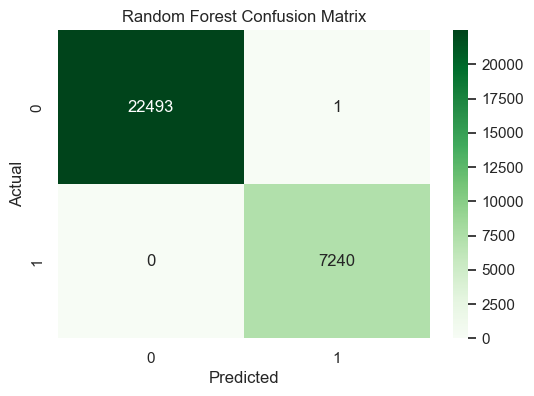

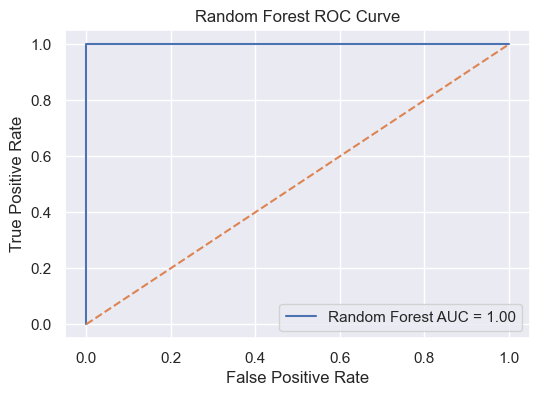

In [51]:
#RANDOM FOREST CONFUSION MATRIX HEATMAP

import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()

#RANDOM FOREST ROC CURVE

fpr_rf, tpr_rf, thresholds_rf = roc_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(6,4))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest AUC = {rf_roc_auc:.2f}'
)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Random Forest ROC Curve")

plt.legend()

plt.show()

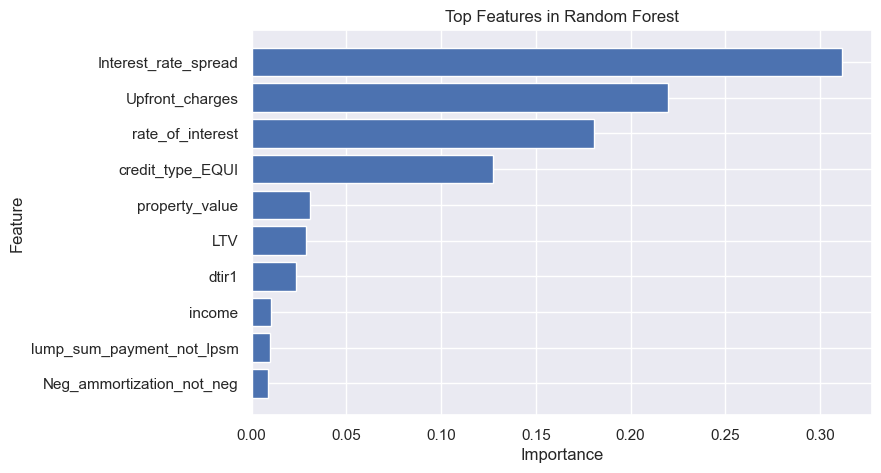

In [53]:
#Which borrower traits were most useful for predicting default risk?
#RANDOM FOREST FEATURE IMPORTANCE

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(20)

#TOP FEATURES FOR RANDOM FOREST

top_rf_features = feature_importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top_rf_features['Feature'],
    top_rf_features['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("Top Features in Random Forest")

plt.gca().invert_yaxis()

plt.show()



## Random Forest Model Summary Report
### The Random Forest model demonstrated extremely strong predictive performance in identifying loan default risk. Based on the confusion matrix, the model correctly classified 22,493 non-default borrowers and 7,240 default borrowers, while producing only 1 false positive and 0 false negatives, indicating that the model was almost perfectly able to separate risky borrowers from safe borrowers within the testing dataset. 

### The ROC curve further supported this observation, with the model achieving a ROC-AUC score close to 1.00, suggesting near-perfect discriminatory ability in distinguishing between default and non-default borrowers. Compared to the earlier Logistic Regression model, the Random Forest model appeared to capture borrower risk patterns much more effectively. 

### Feature importance analysis revealed that Interest_rate_spread, Upfront_charges, rate_of_interest, and credit_type_EQUI were the most influential variables, suggesting that loan pricing structure and financing conditions were strongly associated with default prediction. In particular, borrowers with higher interest rate spreads and higher loan-related charges may have been viewed as riskier borrowers by lenders, causing these variables to become highly predictive within the model. 

### Moderately important variables included property_value, LTV, and dtir1, which are financially meaningful because they reflect collateral value, leverage level, and borrower debt burden. Interestingly, income showed relatively low importance compared to loan pricing variables, suggesting that the structure and cost of the loan may have had a stronger relationship with default risk than borrower salary alone. 

### Overall, the Random Forest model significantly improved predictive performance compared to Logistic Regression by learning complex non-linear relationships and interactions between borrower characteristics and loan conditions, demonstrating the effectiveness of ensemble tree-based models in credit risk prediction and loan default analytics.

In [58]:
#CLEAN COLUMN NAMES FOR XGBOOST

X.columns = [
    col.replace('[', '')
       .replace(']', '')
       .replace('<', '')
    for col in X.columns
]

#NEW TRAIN-TEST SPLIT FOR XGBOOST

from sklearn.model_selection import train_test_split

X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#XGBOOST LOAN DEFAULT PREDICTION

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

#Create XGBoost Model

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

#Train XGBoost Model

xgb_model.fit(X_train_xgb, y_train_xgb)

#Make Predictions

y_pred_xgb = xgb_model.predict(X_test_xgb)

#Probability Predictions
#(needed for ROC-AUC)

y_prob_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]

#Accuracy Score

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:")
print(xgb_accuracy)

#Confusion Matrix

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

#Classification Report

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

#ROC-AUC Score

xgb_roc_auc = roc_auc_score(y_test, y_prob_xgb)

print("\nROC-AUC Score:")
print(xgb_roc_auc)

#accuracy 
accuracy_score(y_test_xgb, y_pred_xgb)

confusion_matrix(y_test_xgb, y_pred_xgb)

classification_report(y_test_xgb, y_pred_xgb)

roc_auc_score(y_test_xgb, y_prob_xgb)

XGBoost Accuracy:
0.9999663684670748

Confusion Matrix:
[[22493     1]
 [    0  7240]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22494
           1       1.00      1.00      1.00      7240

    accuracy                           1.00     29734
   macro avg       1.00      1.00      1.00     29734
weighted avg       1.00      1.00      1.00     29734


ROC-AUC Score:
1.0


np.float64(1.0)

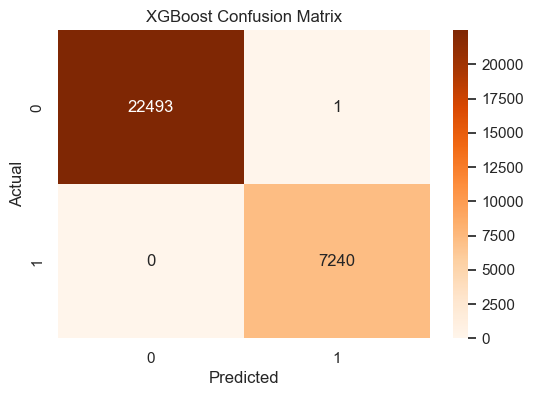

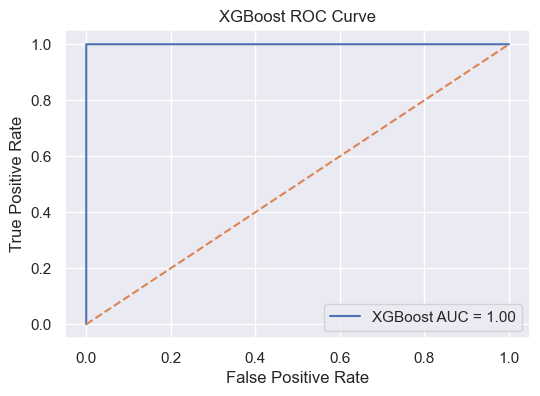

In [63]:
#XGBOOST CONFUSION MATRIX HEATMAP

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_xgb = confusion_matrix(y_test_xgb, y_pred_xgb)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("XGBoost Confusion Matrix")

plt.show()

#XGBOOST ROC CURVE

from sklearn.metrics import roc_curve

fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(
    y_test_xgb,
    y_prob_xgb
)

plt.figure(figsize=(6,4))

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f'XGBoost AUC = {roc_auc_score(y_test_xgb, y_prob_xgb):.2f}'
)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("XGBoost ROC Curve")

plt.legend()

plt.show()

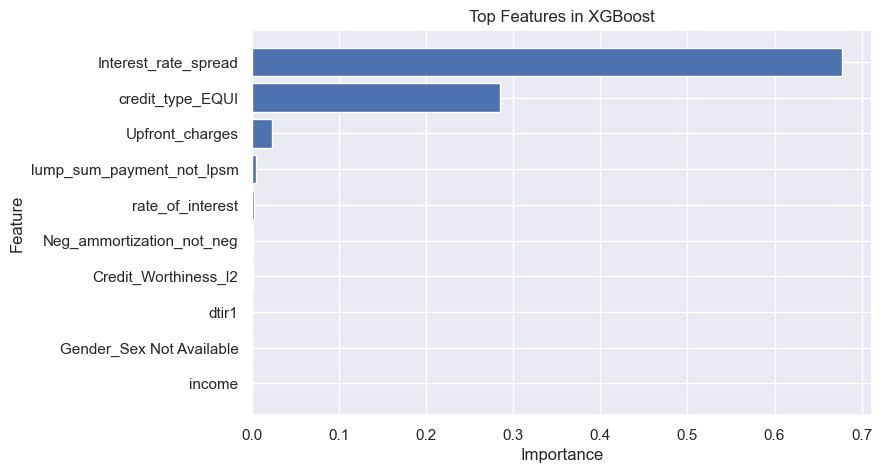

In [64]:
#XGBOOST FEATURE IMPORTANCE

import pandas as pd

xgb_importance = pd.DataFrame({
    'Feature': X_train_xgb.columns,
    'Importance': xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by='Importance',
    ascending=False
)

xgb_importance.head(20)

#TOP FEATURES FOR XGBOOST

top_xgb_features = xgb_importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top_xgb_features['Feature'],
    top_xgb_features['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("Top Features in XGBoost")

plt.gca().invert_yaxis()

plt.show()

## XGBoost Model Summary Report

### The XGBoost model demonstrated exceptionally strong predictive performance in identifying loan default risk, achieving a near-perfect ROC-AUC score of approximately 1.00. Based on the confusion matrix, the model correctly classified 22,493 non-default borrowers and 7,240 default borrowers, while producing only 1 false positive and 0 false negatives. This indicates that the model was almost perfectly able to distinguish between risky and safe borrowers within the testing dataset, showing extremely high predictive capability.

### Feature importance analysis revealed that Interest_rate_spread was by far the most influential variable in the model, followed by credit_type_EQUI and Upfront_charges. This suggests that loan pricing structure, credit type, and financing conditions were strongly associated with borrower default prediction. In particular, higher interest rate spreads may reflect riskier borrower profiles or higher borrowing costs, causing this feature to dominate the model’s decision-making process. Other variables such as dtir1 and income showed relatively low importance compared to the major loan-pricing features.

### Compared to both Logistic Regression and Random Forest, the XGBoost model appeared to capture borrower risk patterns most effectively by sequentially learning from previous prediction errors and modelling complex non-linear relationships between borrower characteristics and loan conditions. Overall, the results suggest that XGBoost is highly effective for credit risk prediction and advanced loan default analytics.


## Supervised Learning Summary and Key Takeaway

### The supervised learning models showed that Logistic Regression, Random Forest, and XGBoost were all effective in predicting borrower default risk, although their performance levels differed significantly. Logistic Regression provided a strong and interpretable baseline model with good predictive ability, but it struggled to detect all risky borrowers due to a higher number of false negatives. In contrast, Random Forest and XGBoost achieved near-perfect predictive performance by learning more complex non-linear relationships between borrower characteristics and loan conditions. Across all models, key financially meaningful variables included Interest_rate_spread, rate_of_interest, Upfront_charges, LTV, and dtir1. The results suggest that borrowers with higher loan pricing costs, higher leverage levels, and greater debt burdens were more likely to default. Overall, the supervised learning analysis showed that loan structure and financing conditions may be more influential in predicting default risk than income alone, highlighting the importance of risk-based lending and borrower financial stress in credit risk analytics.

In [71]:
#K-MEANS CLUSTERING LOAN DEFAULT PROJECT

#Import Libraries

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns


#Load Dataset

loanData = pd.read_csv("Loan_Default.csv")


#Create Working Copy

loanData_cluster = loanData.copy()


#Select Variables for Clustering
# These are financially meaningful numerical variables used to group borrowers into hidden segments
cluster_features = [
    'income',
    'loan_amount',
    'Credit_Score',
    'LTV',
    'dtir1',
    'property_value',
    'Interest_rate_spread',
    'Upfront_charges'
]


#Keep Selected Variables Only

loan_cluster_data = loanData_cluster[cluster_features].copy()


#Handle Missing Values
#Fill missing numerical values using median
#K-Means cannot run if there are NaN values.

for col in loan_cluster_data.columns:
    loan_cluster_data[col] = loan_cluster_data[col].fillna(
        loan_cluster_data[col].median()
    )


#Handle Infinite / Weird Values
#Prevent errors from weird dataset formatting

loan_cluster_data = loan_cluster_data.replace([np.inf, -np.inf], np.nan)

for col in loan_cluster_data.columns:
    loan_cluster_data[col] = loan_cluster_data[col].fillna(
        loan_cluster_data[col].median()
    )


#Standardize Features
#IMPORTANT for K-Means, because clustering is distance-based

scaler = StandardScaler()

loan_cluster_scaled = scaler.fit_transform(loan_cluster_data)


#Elbow Method
#Used to determine optimal number of clusters

wcss = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    kmeans.fit(loan_cluster_scaled)

    wcss.append(kmeans.inertia_)


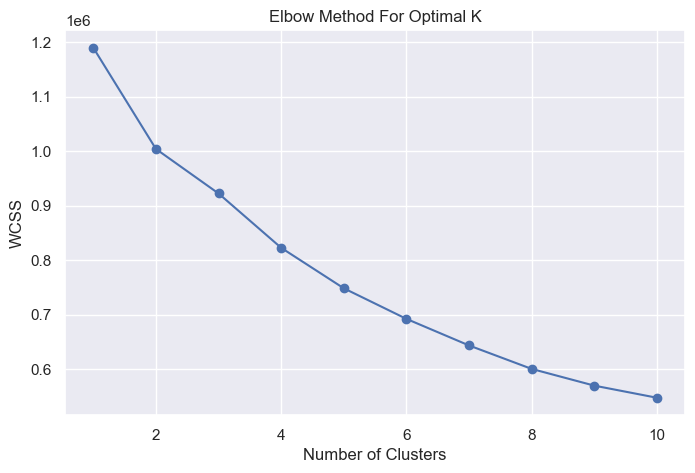

Cluster
1    56349
0    55916
2    36405
Name: count, dtype: int64
               income    loan_amount  Credit_Score        LTV      dtir1  \
Cluster                                                                    
0         5344.011017  259937.656485    803.413066  74.457046  38.711442   
1         5347.928446  258659.754388    597.049761  75.192368  38.722409   
2        11625.484961  552599.436891    699.652355  67.324164  35.537976   

         property_value  Interest_rate_spread  Upfront_charges  
Cluster                                                         
0         367895.021103              0.513757      3030.472361  
1         364530.195744              0.515683      3047.464095  
2         870854.552946              0.164744      3114.129977  

Silhouette Score: 0.13573376124227907


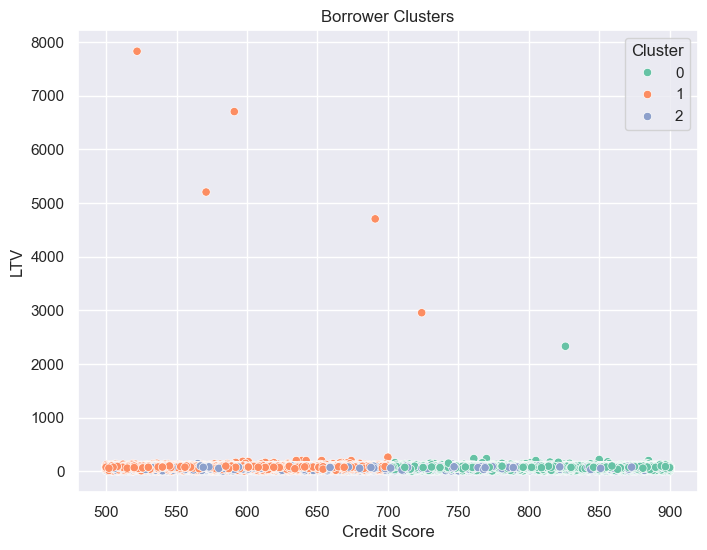

In [72]:
#Plot Elbow Curve

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()


#Final K-Means Model
#CHANGE n_clusters AFTER VIEWING ELBOW CURVE
#Example uses 3 clusters

kmeans_final = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_final.fit_predict(loan_cluster_scaled)


#Add Cluster Labels

loan_cluster_data['Cluster'] = cluster_labels


#Check Cluster Counts

print(loan_cluster_data['Cluster'].value_counts())


#Cluster Mean Analysis
#Analyze average borrower traits per cluster

cluster_summary = loan_cluster_data.groupby('Cluster').mean()

print(cluster_summary)


#Silhouette Score
# Measures clustering quality
# closer to 1 = better separation

sil_score = silhouette_score(
    loan_cluster_scaled,
    cluster_labels
)

print("\nSilhouette Score:", sil_score)


#Cluster Visualization
#Visualize borrower clusters using
#Credit Score vs LTV

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=loan_cluster_data['Credit_Score'],
    y=loan_cluster_data['LTV'],
    hue=loan_cluster_data['Cluster'],
    palette='Set2'
)

plt.title('Borrower Clusters')
plt.xlabel('Credit Score')
plt.ylabel('LTV')

plt.show()

## K-Means Clustering Summary Report

### The K-Means clustering model was used to segment borrowers into different financial profiles based on income, loan amount, Credit Score, LTV, dtir1, property value, Interest rate spread, and Upfront charges.

### Using the elbow method, the WCSS decreased as the number of clusters increased. However, after around 3 clusters, the improvement became more gradual. Therefore, 3 clusters were selected as a reasonable number of borrower segments.

### The final K-Means model separated the borrowers into three main groups:

### Cluster 0 contained around 55,916 borrowers. This group had a high average Credit Score of about 803, moderate income of around 5,344, moderate loan amount, and an LTV of around 74.46. This suggests that Cluster 0 represents stronger credit-quality borrowers. Although their income is not the highest, their strong credit score indicates a more reliable borrower profile.

### Cluster 1 contained around 56,349 borrowers. This group had a much lower average Credit Score of about 597, with income and loan amount levels similar to Cluster 0. Their LTV was also slightly higher at around 75.19. This suggests that Cluster 1 represents higher-risk borrowers because they have weaker credit scores despite having similar income levels to Cluster 0. This shows that income alone is not enough to determine borrower risk.

### Cluster 2 contained around 36,405 borrowers. This group had the highest average income of about 11,625, the highest average loan amount of about 552,599, and the highest property value of about 870,855. At the same time, this group had the lowest LTV of around 67.32 and the lowest dtir1 of around 35.54. This suggests that Cluster 2 represents premium or high-capacity borrowers who take larger loans but appear to have stronger financial capacity and lower relative leverage.

### Overall, the clustering results show that borrowers can be separated into meaningful financial segments. Cluster 0 appears to be strong credit borrowers, Cluster 1 appears to be higher-risk borrowers, and Cluster 2 appears to be premium high-capacity borrowers. The main insight is that borrowers with similar income levels can still have very different risk profiles depending on credit score, leverage, and debt burden.

### However, the Silhouette Score is only about 0.136, which suggests that the clusters are not very strongly separated. This means the segmentation is useful for exploratory borrower profiling, but it should not be treated as a perfect or highly distinct separation of customers. In a real banking context, this clustering would be used as a supporting portfolio analysis tool rather than a final credit decision model.

## Final Project Summary

### This finance loan default project applied machine learning to predict borrower default risk and segment borrowers into meaningful financial profiles.

### For supervised learning, Logistic Regression, Random Forest, and XGBoost were used to predict the target variable `Status`, where 0 represents non-default borrowers and 1 represents default borrowers. Logistic Regression achieved around 87% accuracy and 0.86 ROC-AUC, making it a strong and interpretable baseline model. Random Forest and XGBoost achieved near-perfect ROC-AUC scores, but this also raised a possible concern of information leakage because pricing-related variables such as `Interest_rate_spread`, `Upfront_charges`, and `rate_of_interest` were extremely predictive.

### From the supervised models, `Interest_rate_spread`, `Upfront_charges`, `rate_of_interest`, and `credit_type_EQUI` were found to be among the most important predictors of default. This suggests that borrowers linked to higher financing costs and weaker credit-type categories were more likely to be classified as risky borrowers.

### For unsupervised learning, K-Means clustering was used to segment borrowers into three groups: strong credit borrowers, higher-risk borrowers, and premium high-capacity borrowers. The clustering results showed that Cluster 0 and Cluster 1 had very similar average income levels, around 5,344 and 5,348 respectively, but very different average Credit Scores, around 803 for Cluster 0 compared to 597 for Cluster 1. This suggests that two borrowers can earn similar income but still have very different risk profiles due to credit quality.

### Cluster 2 had the highest average income, loan amount, and property value, but also had the lowest LTV and dtir1. This suggests that higher-income borrowers may take larger loans, but they are not automatically riskier if their leverage and debt burden are lower.

### Overall, the project suggests that loan default risk is more strongly linked to financing pressure and credit quality than income alone. In the supervised models, variables such as `Interest_rate_spread`, `Upfront_charges`, `rate_of_interest`, `LTV`, `dtir1`, and `credit_type_EQUI` were among the strongest signals for default risk. This means borrowers with higher financing costs, higher leverage, heavier debt burden, and weaker credit-type indicators were more likely to be classified as default-risk borrowers. The K-Means clustering results supported this by showing that borrowers with similar income levels could still fall into different risk groups due to differences in credit score, leverage, and debt burden. Overall, this project demonstrates a simplified banking credit risk analytics workflow by combining default prediction, model interpretation, and borrower segmentation.